# WCTE - Ni-Cf source calibration

## Tareas para 27/03/2026

- En los suplots del RECAP DE LOS PLOTS CON CLEAN DATA, el subplot de No. de hits por evento tengo que hacer un corte en 60 (eje x, límite superior). Para el inferior defino 2 límtes independientes: uno tal que el nº de hits por evento esté por encima de 5 y otro tal que el nº de hits por evento esté por encima de 10. Los cortes son para discriminar info que no queremos. Me tienen que salir 2 histogramas? Creo q sí

- Después de estos cortes debo hacer de nuevo los histogramas de carga total por evento, tRMS por evento (esto es importante) y los mean_times, todo con los datos con cortes. Para no liarme con data_clean a estas series nuevas las puedo llamar data_cuts o algo así

- Ahora esto tengo que pensarlo bn: tengo que calcular el vértice de reconstrucción $\vec{x}$ usando los tiempos. Tengo que buscar la posición $x$ que hace que los tiempos medidos y los predichos coincidan lo mejor posible. Osea, distintas posiciones del evento hasta encintrar la que mejor explica los tiempos observados. Tengo que minimizar esta cantidad, por mínimos cuadrados quizás? Básicamente tengo que hacer un fit

In [1]:
import sys
import os
import uproot

# Añade el directorio padre al sys.path
sys.path.append(os.path.abspath("/mnt/netapp2/Store_uni/home/usc/ie/dcr/software/hk"))

import hipy.hipy.pltext  as pltext
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from tqdm import tqdm

pltext.style()

In [2]:
datapath = "/home/usc/ie/tam/nicf_first_semester/NiCf_analysis/teresa_analysis/"    #ahora los csv están en mi carpeta
filename_bkg = "1766_uncut_15kevents.csv"
data_bkg     = pd.read_csv(datapath+filename_bkg)

filename_sig = "1767_uncut_15kevents.csv"
data_sig     = pd.read_csv(datapath+filename_sig)


In [3]:
data_bkg

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids
0,0.0,76264.181597,79.0,27.0,2.0,9.0,3.0
1,0.0,76273.067467,209.0,118.0,55.0,3.0,18.0
2,1.0,209221.084343,103.0,114.0,19.0,13.0,12.0
3,1.0,209223.152791,119.0,114.0,19.0,12.0,4.0
4,1.0,209233.144440,175.0,114.0,19.0,10.0,10.0
...,...,...,...,...,...,...,...
1433051,201316.0,459565.065760,111.0,97.0,92.0,1.0,6.0
1433052,201316.0,459565.813249,82.0,94.0,11.0,6.0,8.0
1433053,201316.0,459568.619830,164.0,32.0,75.0,8.0,9.0
1433054,201317.0,461939.606112,372.0,114.0,19.0,3.0,18.0


In [4]:
data_sig

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids
0,0.0,53683.787124,117.0,108.0,3.0,14.0,13.0
1,0.0,53691.537798,100.0,102.0,22.0,10.0,10.0
2,1.0,63479.663380,83.0,12.0,1.0,15.0,5.0
3,1.0,63480.392541,133.0,36.0,46.0,13.0,12.0
4,1.0,63496.106182,180.0,96.0,8.0,15.0,5.0
...,...,...,...,...,...,...,...
3361704,455342.0,492800.972765,237.0,78.0,33.0,11.0,11.0
3361705,455342.0,492801.767311,123.0,85.0,93.0,4.0,1.0
3361706,455342.0,492801.914035,140.0,20.0,81.0,17.0,15.0
3361707,455342.0,492802.180405,221.0,100.0,24.0,2.0,0.0


El proceso es el siguiente:

$^{252}\text{Cf}\rightarrow ^{148}\text{Ba}+^{106}\text{Mo}+4n$

$^{58}\text{Ni}+n\rightarrow ^{59}\text{Ni}+\gamma$

Los fotones son los que se detectan, vemos que en este run detectamos 1433056 fotones (hits) de background. Para organizar esta gigantesca información definimos los "eventos", que corresponden a la toma de datos en un intervalo de tiempo de 500 [microsegundos], cada uno con un número variable de fotones que llegan al WCTE. Indexamos los eventos con el event_id. En estos eventos debemos separar el "ruido" de los candidates (fotones registrados que provienen del decay del $^{58}\text{Ni}$).

Como me interesan los eventos agrupo los hits en su evento correspondiente con .groupby(). Sumo hit_pmt_charges (carga total en cada evento), cuento cuántos hits tiene cada evento (cuántos fotones tiene cada evento), y la RMS del tiempo (si trms es pequeña los hits han llegado casi al mismo tiempo al PMT en este evento).

In [5]:
data_by_event_bkg=data_bkg.groupby("event_id")

total_charge_by_event_bkg = data_by_event_bkg["hit_pmt_charges"].sum() #data_by_event["hit_pmt_charges"] con los [] seleccionamos
total_nhits_by_event_bkg = data_by_event_bkg.size() #.size() devuelve el nº de elementos, osea el nº de hits en cada evento
total_trms_by_event_bkg  = data_by_event_bkg["hit_pmt_calibrated_times"].std() #.std() ya lo calcula q facil, pero por q se le llama total_trms?? No hay solo una?

print(f"Tenemos {len(data_by_event_bkg)} eventos (grupos de hits) de bkg") #este será nuestro eje x en los scatters

data_by_event_sig=data_sig.groupby("event_id")
total_charge_by_event_sig=data_by_event_sig["hit_pmt_charges"].sum()
total_nhits_by_event_sig = data_by_event_sig.size()
total_trms_by_event_sig  = data_by_event_sig["hit_pmt_calibrated_times"].std()

print(f"Tenemos {len(data_by_event_sig)} eventos (grupos de hits) de sig+bkg") #este será nuestro eje x en los scatters

Tenemos 201318 eventos (grupos de hits) de bkg
Tenemos 455343 eventos (grupos de hits) de sig+bkg


Hemos almacenado la carga total por evento, el nº de hits por evento y la trms por evento en series: total_charge_by_event_bkg, total_nhits_by_event_bkg, total_trms_by_event_bkg (igual para los datos de señal). Ahora hacemos un gráfico de dispersión (scatter plot, no une los puntos) de cada serie frente el índice que indexa cada evento.

plt.scatter(x.index, y.values) ; .index indexa los elementos de la serie y coge los índices, .values da los valores

Text(0.5, 0.93, 'Muestras iniciales (contaminadas)')

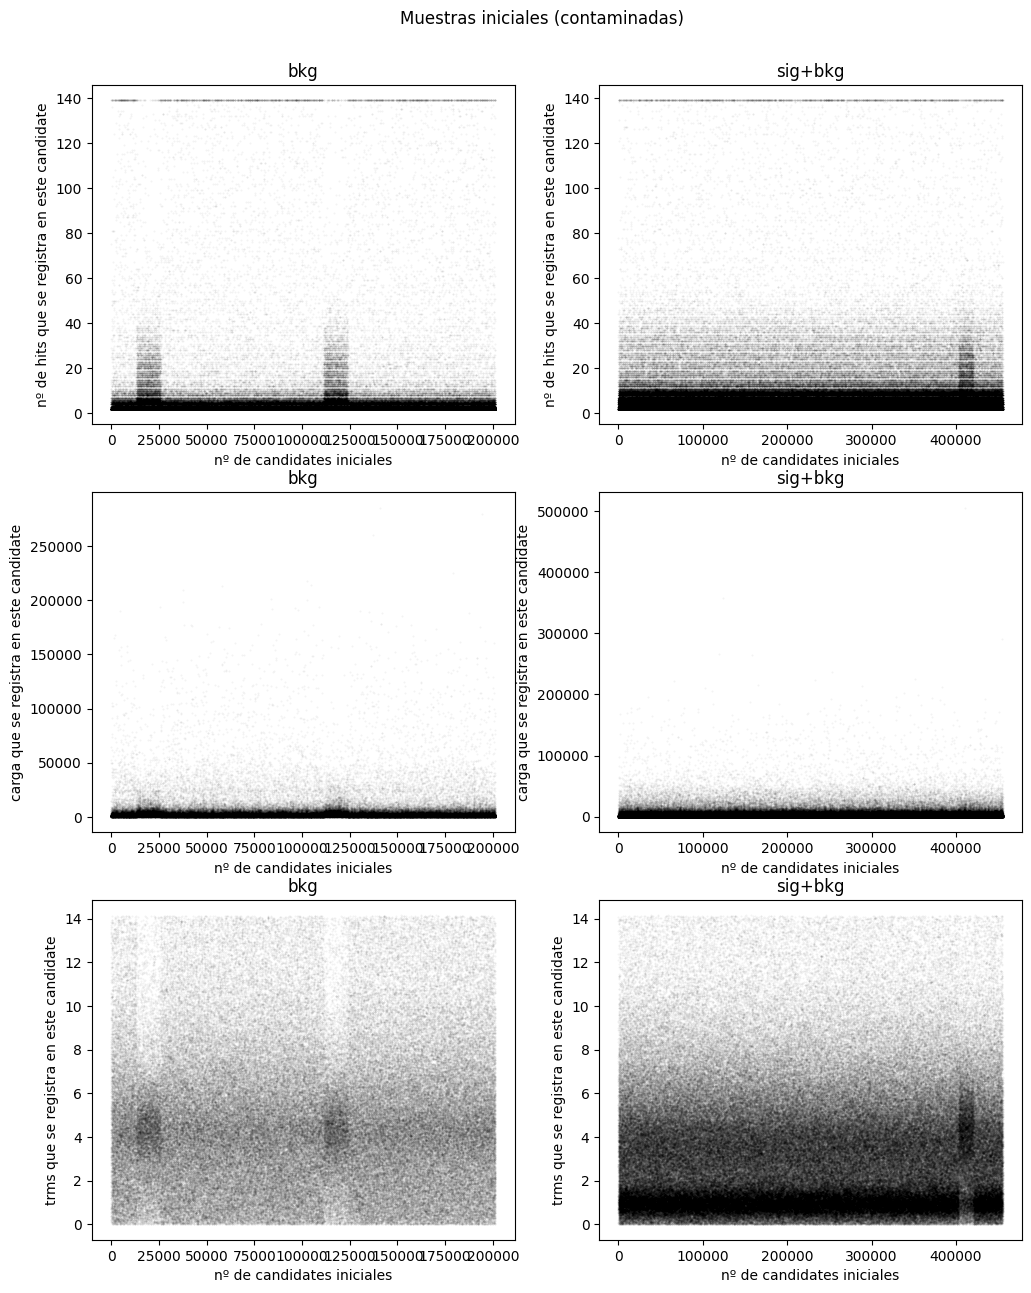

In [6]:
subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")

subplot(3)
plt.scatter(total_charge_by_event_bkg.index, total_charge_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("carga que se registra en este candidate")
plt.title("bkg")

subplot(4)
plt.scatter(total_charge_by_event_sig.index, total_charge_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("carga que se registra en este candidate")
plt.title("sig+bkg")

subplot(5)
plt.scatter(total_trms_by_event_bkg.index, total_trms_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("trms que se registra en este candidate")
plt.title("bkg")

subplot(6)
plt.scatter(total_trms_by_event_sig.index, total_trms_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("trms que se registra en este candidate")
plt.title("sig+bkg")

plt.suptitle("Muestras iniciales (contaminadas)", y=0.93)

## Muestras de candidates descontaminadas

Utilizaremos el scatter "nº total de hits de cada candidate vs nº de candidate" para eliminar los eventos que no nos interesan y quedarnos con los candidates buenos. Hago de nuevo este scatter:

Text(0.5, 0.98, 'nº total de hits de cada candidate vs nº de candidate')

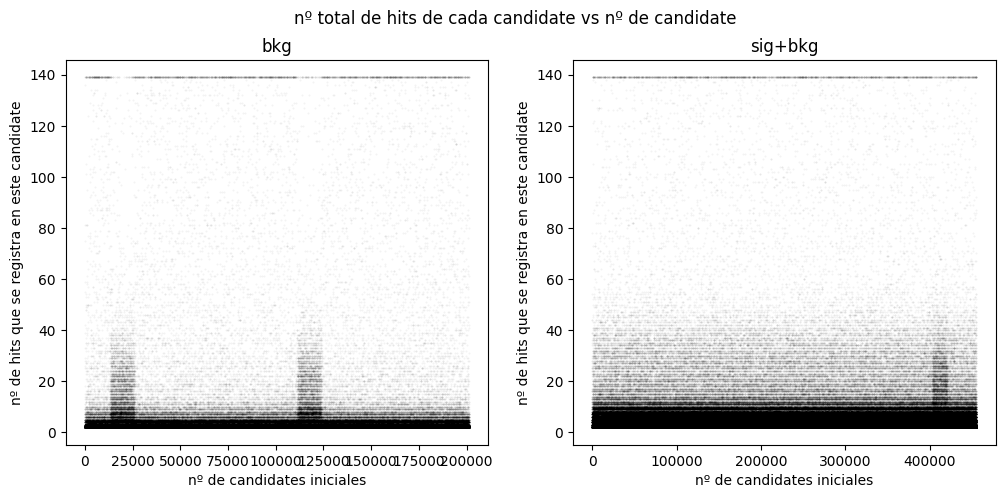

In [7]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates iniciales")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")

plt.suptitle("nº total de hits de cada candidate vs nº de candidate")

In [8]:
#quiero quitar los spills y los que saturan

#lo lógico primero es bucar cuál es el valor exacto de saturación:
max_value_of_total_nhits_by_event_bkg = total_nhits_by_event_bkg.max()  #aquí .max() va con () porque realiza un cálculo

print("Quito los valores saturantes bkg")
print(f"{max_value_of_total_nhits_by_event_bkg} es el valor al que satura el nº de hits en los candidates para bkg")

#ahora quiero agrupar los eventos en los que este valor satura, filtrando los eventos en los que total_nhits_by_event_bkg coincida (==) con max_value_of_total_nhits_by_event_bkg
events_saturating_bkg = total_nhits_by_event_bkg[total_nhits_by_event_bkg == max_value_of_total_nhits_by_event_bkg]
print(f"{len(events_saturating_bkg)} eventos de bkg que saturan a este valor")

#ahora quiero quitar estos eventos:

#total_nhits_by_event_bkg_without_saturation = total_nhits_by_event_bkg - events_saturating
#esto no funciona xq son series de pandas
#uso mejor .drop(x), que elimina el índice x de una serie

indices_saturating_bkg = events_saturating_bkg.index
print(indices_saturating_bkg)
total_nhits_by_event_bkg_only_spills = total_nhits_by_event_bkg.drop(indices_saturating_bkg)    #serie sin los valores que saturan

#number_of_saturating_values_bkg = len(total_nhits_by_event_bkg)-len(total_nhits_by_event_bkg_only_spills)


print(f"La muestra inicial tiene {len(total_nhits_by_event_bkg)} eventos de bkg, al quitar los valores saturantes nos quedan {len(total_nhits_by_event_bkg_only_spills)} eventos (estos tienen spills)")
print(f"Hemos quitado {len(total_nhits_by_event_bkg)-len(total_nhits_by_event_bkg_only_spills)} eventos de bkg, q es el {(len(total_nhits_by_event_bkg)-len(total_nhits_by_event_bkg_only_spills))/len(total_nhits_by_event_bkg)*100:.4f}% de la muestra inicial")
print(f"Nos queda el {100-((len(total_nhits_by_event_bkg)-len(total_nhits_by_event_bkg_only_spills))/len(total_nhits_by_event_bkg)*100):.4f} % de la muestra inicial de bkg")


print("\n"); print("="*80)


#igual para signal
max_value_of_total_nhits_by_event_sig = total_nhits_by_event_sig.max()
print("Quito los valores saturantes sig+bkg")
print(f"{max_value_of_total_nhits_by_event_sig} es el valor al que satura el nº de hits en los candidates para sig+bkg")
events_saturating_sig = total_nhits_by_event_sig[total_nhits_by_event_sig == max_value_of_total_nhits_by_event_sig]
print(f"{events_saturating_sig.size} eventos de sig+bkg que saturan a este valor")
indices_saturating_sig = events_saturating_sig.index
print(indices_saturating_sig)
total_nhits_by_event_sig_only_spills = total_nhits_by_event_sig.drop(indices_saturating_sig)

print(f"La muestra inicial tiene {len(total_nhits_by_event_sig)} eventos de sig+bkg, al quitar los valores saturantes nos quedan {len(total_nhits_by_event_sig_only_spills)} eventos (estos tienen spills)")
print(f"Hemos quitado {len(total_nhits_by_event_sig)-len(total_nhits_by_event_sig_only_spills)} eventos de sig+bkg, q es el {(len(total_nhits_by_event_sig)-len(total_nhits_by_event_sig_only_spills))/len(total_nhits_by_event_sig)*100:.4f}% de la muestra inicial")
print(f"Nos queda el {100-((len(total_nhits_by_event_sig)-len(total_nhits_by_event_sig_only_spills))/len(total_nhits_by_event_sig)*100):.4f} % de la muestra inicial de sig+bkg")



Quito los valores saturantes bkg
139 es el valor al que satura el nº de hits en los candidates para bkg
1888 eventos de bkg que saturan a este valor
Index([    57.0,    182.0,    443.0,    593.0,    651.0,    666.0,    670.0,
          678.0,    777.0,    877.0,
       ...
       200196.0, 200348.0, 200659.0, 200871.0, 200887.0, 200913.0, 201052.0,
       201076.0, 201193.0, 201249.0],
      dtype='float64', name='event_id', length=1888)
La muestra inicial tiene 201318 eventos de bkg, al quitar los valores saturantes nos quedan 199430 eventos (estos tienen spills)
Hemos quitado 1888 eventos de bkg, q es el 0.9378% de la muestra inicial
Nos queda el 99.0622 % de la muestra inicial de bkg


Quito los valores saturantes sig+bkg
139 es el valor al que satura el nº de hits en los candidates para sig+bkg
1958 eventos de sig+bkg que saturan a este valor
Index([   438.0,    513.0,    752.0,    799.0,    891.0,    913.0,   1076.0,
         1105.0,   1638.0,   1821.0,
       ...
       454490.0,

In [9]:
type(indices_saturating_bkg)

pandas.core.indexes.base.Index

Text(0.5, 0.98, 'nº total de hits de cada candidate vs nº de candidate')

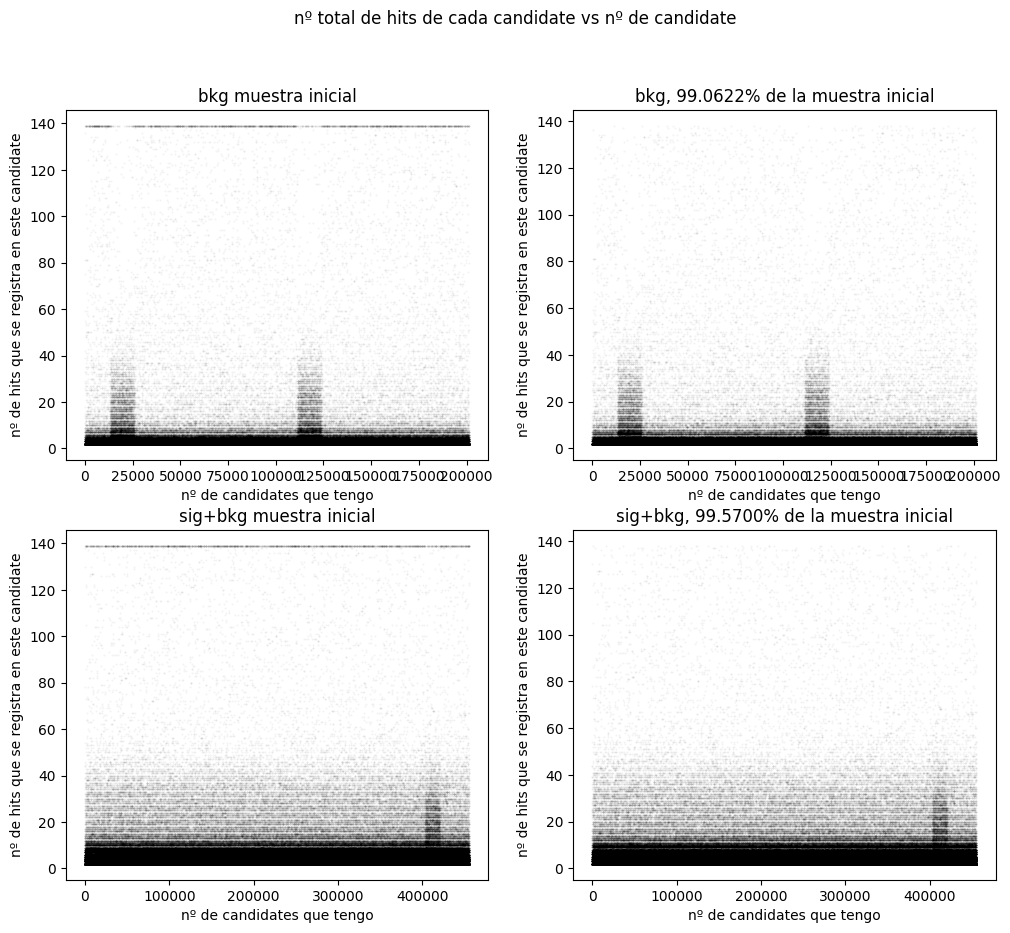

In [10]:
subplot = pltext.canvas(4)      #scattereo las dos (con y sin candidates saturantes) para verlo bien

subplot(1)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg muestra inicial")


subplot(2)
plt.scatter(total_nhits_by_event_bkg_only_spills.index, total_nhits_by_event_bkg_only_spills.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title(f"bkg, {100-((len(total_nhits_by_event_bkg)-len(total_nhits_by_event_bkg_only_spills))/len(total_nhits_by_event_bkg)*100):.4f}% de la muestra inicial")

subplot(3)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg muestra inicial")

subplot(4)
plt.scatter(total_nhits_by_event_sig_only_spills.index, total_nhits_by_event_sig_only_spills.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title(f"sig+bkg, {100-(len(total_nhits_by_event_sig)-len(total_nhits_by_event_sig_only_spills))/len(total_nhits_by_event_sig)*100:.4f}% de la muestra inicial")

plt.suptitle("nº total de hits de cada candidate vs nº de candidate")

(390000.0, 440000.0)

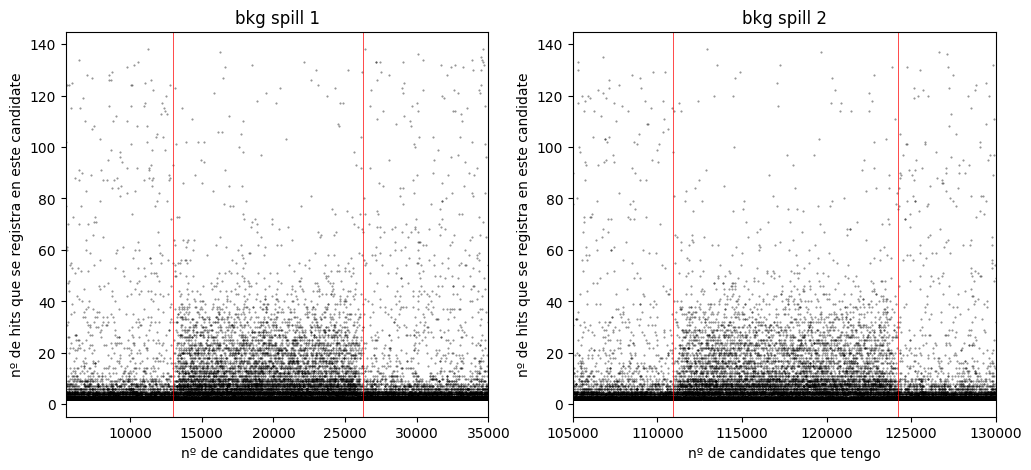

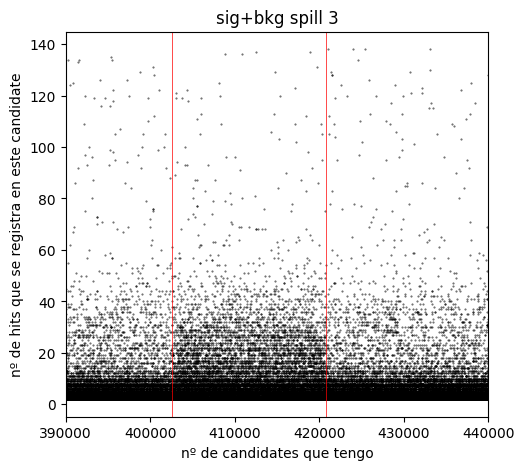

In [11]:
#vale ahora tengo que quitar los dos spills

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_nhits_by_event_bkg_only_spills.index, total_nhits_by_event_bkg_only_spills.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spill 1")

x_lines_spill1 = [13000, 26250]     #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
for x in x_lines_spill1:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(5500, 35000)
#plt.ylim(0,140)

subplot(2)
plt.scatter(total_nhits_by_event_bkg_only_spills.index, total_nhits_by_event_bkg_only_spills.values, s=0.2, alpha=0.5)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg spill 2")

x_lines_spill2 = [110900, 124250]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
for x in x_lines_spill2:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(105000, 130000)
#plt.ylim(0,140)

subplot = pltext.canvas(1)
subplot(1)
plt.scatter(total_nhits_by_event_sig_only_spills.index, total_nhits_by_event_sig_only_spills.values, s=0.2, alpha=0.7)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg spill 3")

x_lines_spill3 = [402600, 420800]   #dibujo los límites (a ojo, seguro que hay otra forma más eficiente de hacerlo)
for x in x_lines_spill3:
    plt.axvline(x=x, color="r", linestyle="-", linewidth=0.5) 

plt.xlim(390000, 440000)
#plt.ylim(0,140)


In [12]:
x_min_s1 = 13000; x_max_s1 = 26250
x_min_s2 = 110900; x_max_s2 = 124250
x_min_s3 = 402600; x_max_s3 = 420800


#series que hay que quitar
spill_1 = total_nhits_by_event_bkg_only_spills[(total_nhits_by_event_bkg_only_spills.index >= x_min_s1) & (total_nhits_by_event_bkg_only_spills.index <= x_max_s1)]
spill_2 = total_nhits_by_event_bkg_only_spills[(total_nhits_by_event_bkg_only_spills.index >= x_min_s2) & (total_nhits_by_event_bkg_only_spills.index <= x_max_s2)]
spill_3 = total_nhits_by_event_sig_only_spills[(total_nhits_by_event_sig_only_spills.index >= x_min_s3) & (total_nhits_by_event_sig_only_spills.index <= x_max_s3)]

#hay que concatenar sus índices, NO SUMAR. Esto es para bkg porq tiene 2 spills
combined_indices_bkg = pd.concat([spill_1, spill_2]).index  

total_nhits_by_event_bkg_clean = total_nhits_by_event_bkg_only_spills.drop(combined_indices_bkg)
total_charge_by_event_bkg_clean = total_charge_by_event_bkg.loc[total_nhits_by_event_bkg_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_event_bkg_clean = total_trms_by_event_bkg.loc[total_nhits_by_event_bkg_clean.index]

total_nhits_by_event_sig_clean = total_nhits_by_event_sig_only_spills.drop(spill_3.index)
total_charge_by_event_sig_clean = total_charge_by_event_sig.loc[total_nhits_by_event_sig_clean.index]   #.loc[] para el filtrado del resto de series
total_trms_by_event_sig_clean = total_trms_by_event_sig.loc[total_nhits_by_event_sig_clean.index]


###

print(f"Hemos juntado en una pd.Series con {len(pd.concat([spill_1, spill_2]))} eventos los dos spills de bkg, que representa el {len(pd.concat([spill_1, spill_2]))/len(total_nhits_by_event_bkg)*100:.4f}% de la muestra inicial y el {len(pd.concat([spill_1, spill_2]))/len(total_nhits_by_event_bkg_only_spills)*100:.4f}% de l amuestra sólo con spills")
print(f"Nos queda la pd.Series descontaminada (clean), con {len(total_nhits_by_event_bkg_only_spills)-len(pd.concat([spill_1, spill_2]))} eventos que representan el {(len(total_nhits_by_event_bkg_only_spills)-len(pd.concat([spill_1, spill_2])))/len(total_nhits_by_event_bkg_only_spills)*100:.4f}% de la muestra inicial de bkg")
print(f"En total, hemos quitado {len(total_nhits_by_event_bkg)-len(total_charge_by_event_bkg_clean)} eventos de bkg")

print("\n")

print(f"Para sig+bkg tenemos {len(spill_3)} eventos en el único spill que hay (spill_3), que representa el {len(spill_3)/len(total_nhits_by_event_sig)*100:.4f}% de la muestra inicial y el {len(spill_3)/len(total_nhits_by_event_sig_only_spills)*100:.4f}% de l amuestra sólo con spills")
print(f"Nos queda la pd.Series descontaminada (clean), con {len(total_nhits_by_event_sig_only_spills)-len(spill_3)} eventos que representan el {(len(total_nhits_by_event_sig_only_spills)-len(spill_3))/len(total_nhits_by_event_sig_only_spills)*100:.4f}% de la muestra inicial de sig+bkg")
print(f"En total, hemos quitado {len(total_nhits_by_event_sig)-len(total_charge_by_event_sig_clean)} eventos de sig+bkg")

#print("\n")
#print(f"En sig+bkg hay {len(total_nhits_by_event_sig)} eventos")
#print(f"Los valores saturantes constituyen {len(total_nhits_by_event_sig_only_spills)} eventos")
#print(f"En la serie del spill 3 hay {len(spill_3)} eventos")




Hemos juntado en una pd.Series con 26515 eventos los dos spills de bkg, que representa el 13.1707% de la muestra inicial y el 13.2954% de l amuestra sólo con spills
Nos queda la pd.Series descontaminada (clean), con 172915 eventos que representan el 86.7046% de la muestra inicial de bkg
En total, hemos quitado 28403 eventos de bkg


Para sig+bkg tenemos 18153 eventos en el único spill que hay (spill_3), que representa el 3.9867% de la muestra inicial y el 4.0039% de l amuestra sólo con spills
Nos queda la pd.Series descontaminada (clean), con 435232 eventos que representan el 95.9961% de la muestra inicial de sig+bkg
En total, hemos quitado 20111 eventos de sig+bkg


In [13]:
type(pd.concat([spill_1, spill_2]))

pandas.core.series.Series

Text(0.5, 0.92, 'Muestras descontaminadas')

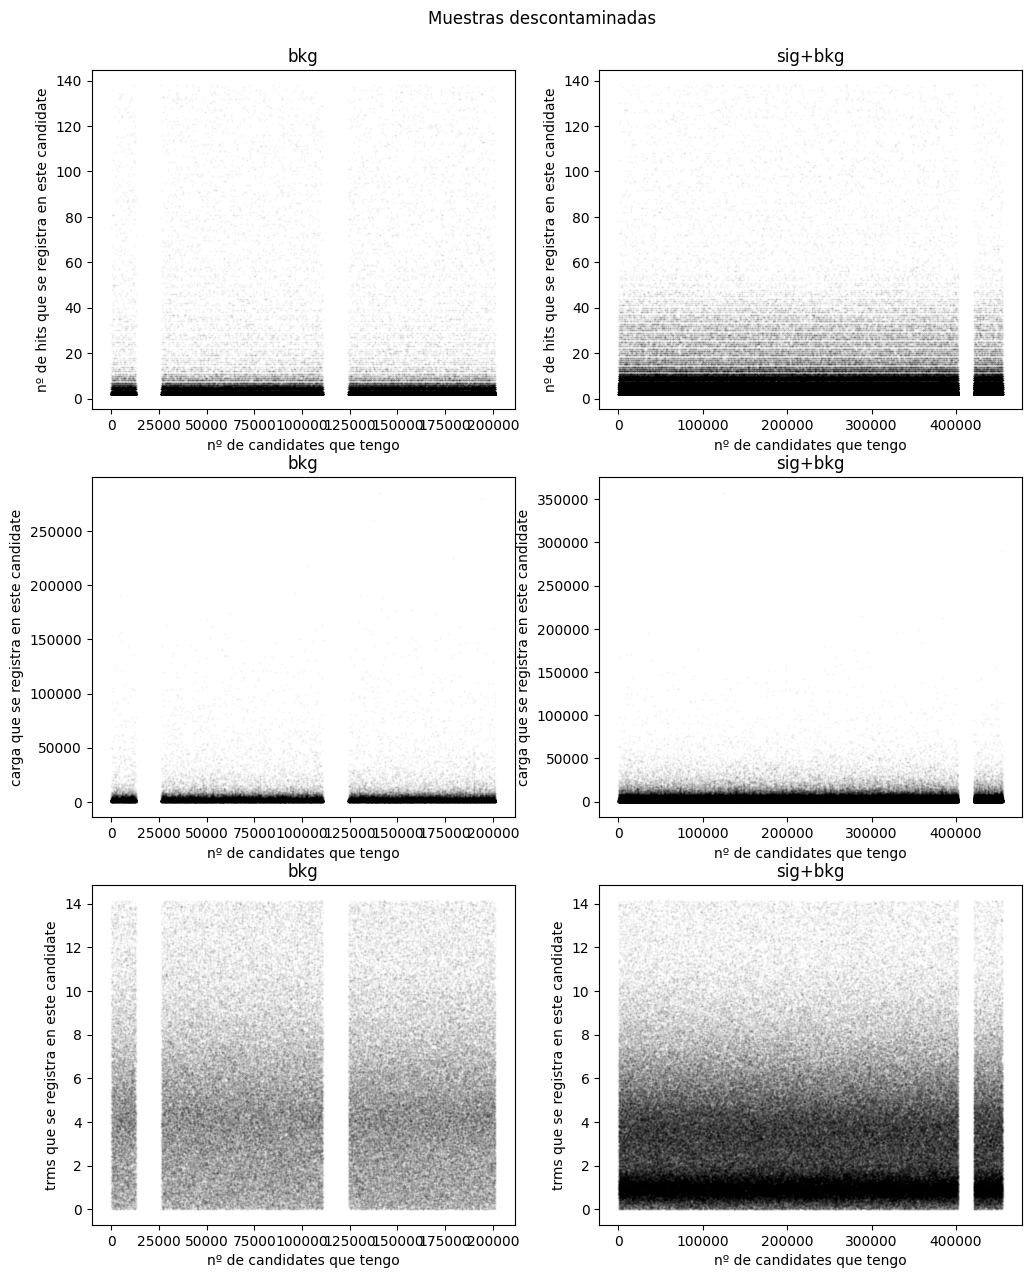

In [14]:
subplot = pltext.canvas(6)

subplot(1)
plt.scatter(total_nhits_by_event_bkg_clean.index, total_nhits_by_event_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("bkg")

subplot(2)
plt.scatter(total_nhits_by_event_sig_clean.index, total_nhits_by_event_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")    #NO SE LLAMABAN CANDIDATES
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("sig+bkg")


subplot(3)
plt.scatter(total_charge_by_event_bkg_clean.index, total_charge_by_event_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("bkg")

subplot(4)
plt.scatter(total_charge_by_event_sig_clean.index, total_charge_by_event_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registra en este candidate")
plt.title("sig+bkg")


subplot(5)
plt.scatter(total_trms_by_event_bkg_clean.index, total_trms_by_event_bkg_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("bkg")

subplot(6)
plt.scatter(total_trms_by_event_sig_clean.index, total_trms_by_event_sig_clean.values, s=0.2, alpha=0.05)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("trms que se registra en este candidate")
plt.title("sig+bkg")

plt.suptitle("Muestras descontaminadas", y=0.92)


# Distribución de hits por evento

Text(0.5, 0.98, 'Distribución de hits por evento')

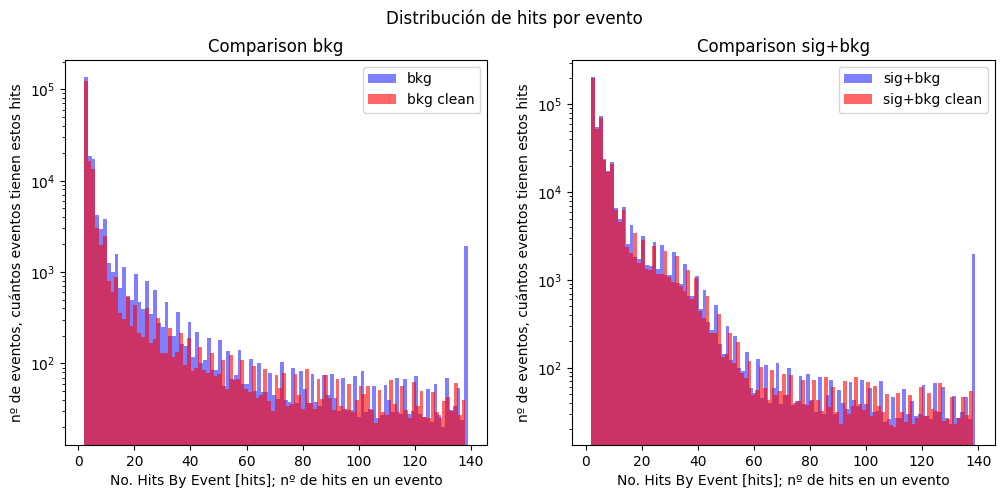

In [15]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_nhits_by_event_bkg, 100, histtype="stepfilled", label="bkg", alpha=0.5, color="b")   #500 bins; histtype = "stepfilled" rellena el bin
plt.hist(total_nhits_by_event_bkg_clean, 100, histtype="stepfilled", label="bkg clean", alpha=0.6, color="r")
plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Comparison bkg")
plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_nhits_by_event_sig, 100, histtype="stepfilled", label="sig+bkg", alpha=0.5, color="b")
plt.hist(total_nhits_by_event_sig_clean, 100, histtype="stepfilled", label="sig+bkg clean", alpha=0.6, color="r")
plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Comparison sig+bkg")
plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de hits por evento")

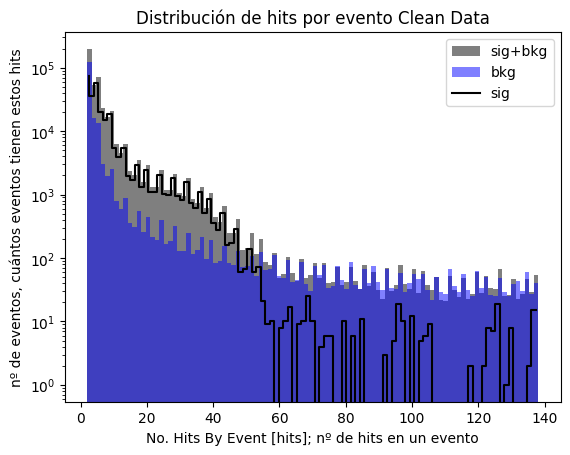

In [16]:
counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_event_bkg_clean, 100, histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_nhits = (edges_sig_nhits[:-1] + edges_sig_nhits [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits, counts_sig_nhits - counts_bkg_nhits, label="sig", color="k") ;


weights_sig_nhits = np.ones_like(total_nhits_by_event_sig_clean)
weights_bkg_nhits_4 = -  1*np.ones_like(total_nhits_by_event_bkg_clean)   #bkg = sig+bkg perfecto
all_nhits = np.concatenate([total_nhits_by_event_sig_clean, total_nhits_by_event_bkg_clean])   #lo junto todo
all_weights_nhits_4 = np.concatenate([weights_sig_nhits, weights_bkg_nhits_4])
#plt.hist(all_nhits, 100, weights=all_weights_nhits_4, histtype="step", color="r", alpha=1, label="sig4, not correct")


plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()

# Distribución de carga total por evento

Text(0.5, 0.98, 'Distribución de carga total por evento')

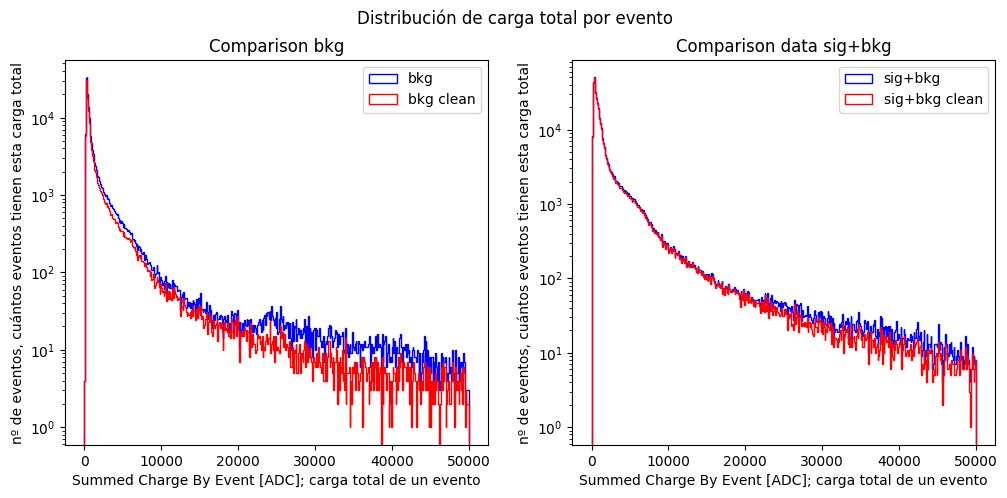

In [17]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_charge_by_event_bkg, 500, histtype="step", label="bkg", range=(0, 50e3), color="b")   #500 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_event_bkg_clean, 500, histtype="step", label="bkg clean", range=(0, 50e3), color="r")
plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Comparison bkg")
plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_charge_by_event_sig, 500, histtype="step", label="sig+bkg", range=(0, 50e3), color="b")   #500 bins; histtype = "step" dibuja el contorno de las barras
plt.hist(total_charge_by_event_sig_clean, 500, histtype="step", label="sig+bkg clean", range=(0, 50e3), color="r")
plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Comparison data sig+bkg")
plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de carga total por evento")

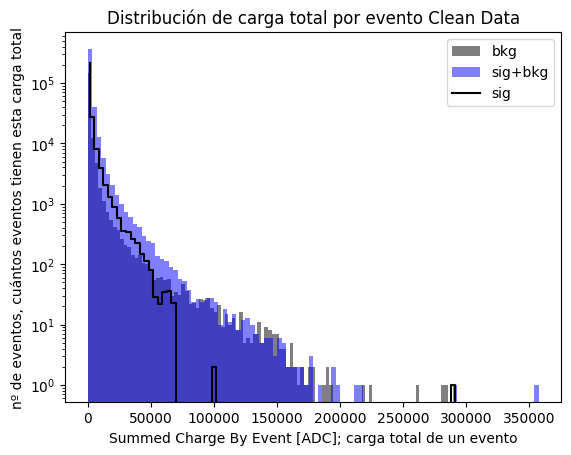

In [42]:
counts_bkg_charge, edges_bkg_charge, _ = plt.hist(total_charge_by_event_bkg_clean, 100, histtype = "stepfilled" ,alpha=0.5, label="bkg")    #recoge los valores x,y que dibuja en el histograma
counts_sig_charge, edges_sig_charge, _ = plt.hist(total_charge_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg")
#para ver mejor range=(0,2000)

bin_centers_charge = (edges_sig_charge[1:] + edges_sig_charge [:-1])/2   #divide entre 2 porque calcula el centro del bin

#total_charge_by_event_only_sig = pd.Series(counts_sig_charge - counts_bkg_charge, index=bin_centers_charge) #creo la pd.Series de la señal limpia (sólo la señal)
#plt.hist(counts_sig_charge - counts_bkg_charge, 100, histtype = "stepfilled" ,alpha=1, label="sig") # ESTÁ MAL???

plt.step(bin_centers_charge, counts_sig_charge - counts_bkg_charge, label="sig", color="k")


#esto es lo que hice yo, está mal
weights_sig_charge = np.ones_like(total_charge_by_event_sig_clean)
weights_bkg_charge_4 = -  1*np.ones_like(total_charge_by_event_bkg_clean)   #asumimos normaliz bkg = sig+bkg perfecto
all_charge = np.concatenate([total_charge_by_event_sig_clean, total_charge_by_event_bkg_clean])   #lo junto todo
all_weights_charge_4 = np.concatenate([weights_sig_charge, weights_bkg_charge_4])
#plt.hist(all_charge, 100, weights=all_weights_charge_4, histtype="step", color="r", alpha=1, label="sig4, not correct")

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
#plt.xlim(0,20000)
plt.legend()

Bins discretos (con separación) porque el nº de hits en un evento es entero. En realidad es que hay bins vacíos de por medio, pero esto se puede ajustar cambiando el número de bins que quiero que grafique (por ej de 500 cambiamos a 50). Con los candidates buenos quitamos el bin en 139, vemos que hay una meseta entre 17 y 40 hits. Si hacemos el corte nos quedamos con los eventos que tienen < 60 hits. 

# Distribución de tRMS por evento

Text(0.5, 0.98, 'Distribución de tRMS por evento')

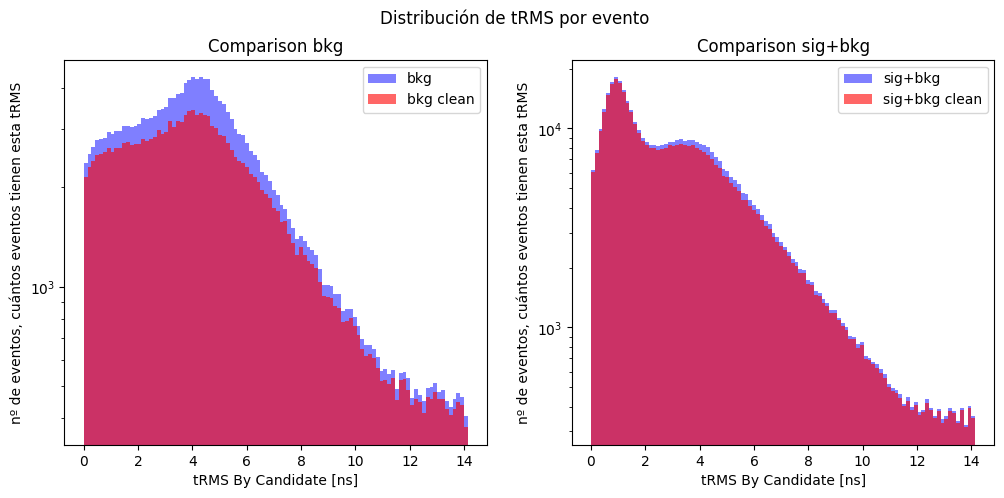

In [19]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_trms_by_event_bkg, 100, histtype="stepfilled", alpha=0.5, label="bkg", color="b")
plt.hist(total_trms_by_event_bkg_clean, 100, histtype="stepfilled", alpha=0.6, label="bkg clean", color="r")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.title("Comparison bkg")
plt.yscale("log")
plt.legend()

subplot(2)
plt.hist(total_trms_by_event_sig, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg", color="b")
plt.hist(total_trms_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.6, label="sig+bkg clean", color="r")
#plt.hist(all_trms, 500, weights=all_weights_trms_4, histtype="step", color="cyan", alpha=1, label="sig")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.title("Comparison sig+bkg")
plt.yscale("log")
plt.legend()

plt.suptitle("Distribución de tRMS por evento")



La tRMS es la desviación estándar de los tiempos de llegada de los hits en un evento. Si los hits que forman un evento llegaran a la vez, el tRMS sería cero, i.e., cuanto más dispersos en el tiempo, mayor será la tRMS. Vemos que el pico corresponde a que hay muchos eventos con tRMS pequeña (los hits llegan casi a la vez). Que haya esta diferencia tan marcada entre bkg y sig+bkg sugiere que el detector tiene buena resolución para identificar candidates deseados basándose en el tiempo.

Si quiero hacer un corte para quedarme solo con los eventos más probables de ser reales lo haría en tRMS < 2 [ns]: conservo gran parte de sig (pico) y elimino gran parte del bkg.

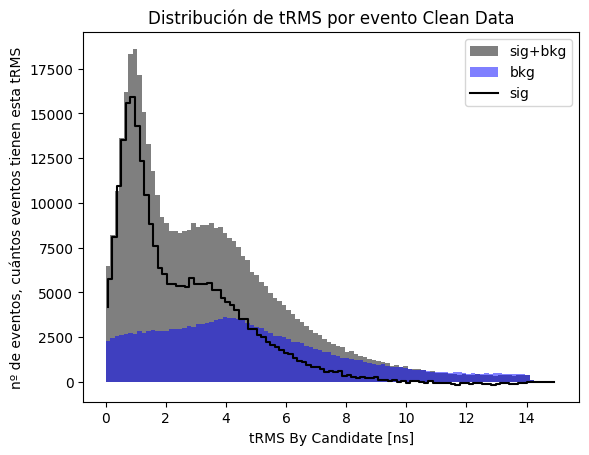

In [36]:
counts_sig_trms, edges_sig_trms, _ = plt.hist(total_trms_by_event_sig_clean, 100, range=(0,15), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_trms, edges_bkg_trms, _ = plt.hist(total_trms_by_event_bkg_clean, 100, range=(0,15), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_trms = (edges_sig_trms[:-1] + edges_sig_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms, counts_sig_trms - counts_bkg_trms, label="sig", color="k") ; #Esto que plotea ya es la resta bin a bin, pero no era que no tenían la misma longitud???
#Este código separa los dos arrays de hist (así después me evito tener que usar weights y es solo hacer una resta)


#total_trms_by_event_pure_sig = total_trms_by_event_sig_clean - total_trms_by_event_bkg_clean  Esto no funciona porque son series de longitudes diferentes, mmm no?

weights_sig_trms = np.ones_like(total_trms_by_event_sig_clean)
weights_bkg_trms_4 = -  1*np.ones_like(total_trms_by_event_bkg_clean)   #bkg = sig+bkg perfecto

all_trms = np.concatenate([total_trms_by_event_sig_clean, total_trms_by_event_bkg_clean])   #lo junto todo
all_weights_trms_4 = np.concatenate([weights_sig_trms, weights_bkg_trms_4])

#plt.hist(all_trms, 100, weights=all_weights_trms_4, histtype="step", alpha=1, label="sig4, not correct", color="r")

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()

#plt.yscale("log")

# RECAP DE LOS PLOTS CON CLEAN DATA + CORTES CON MASKS

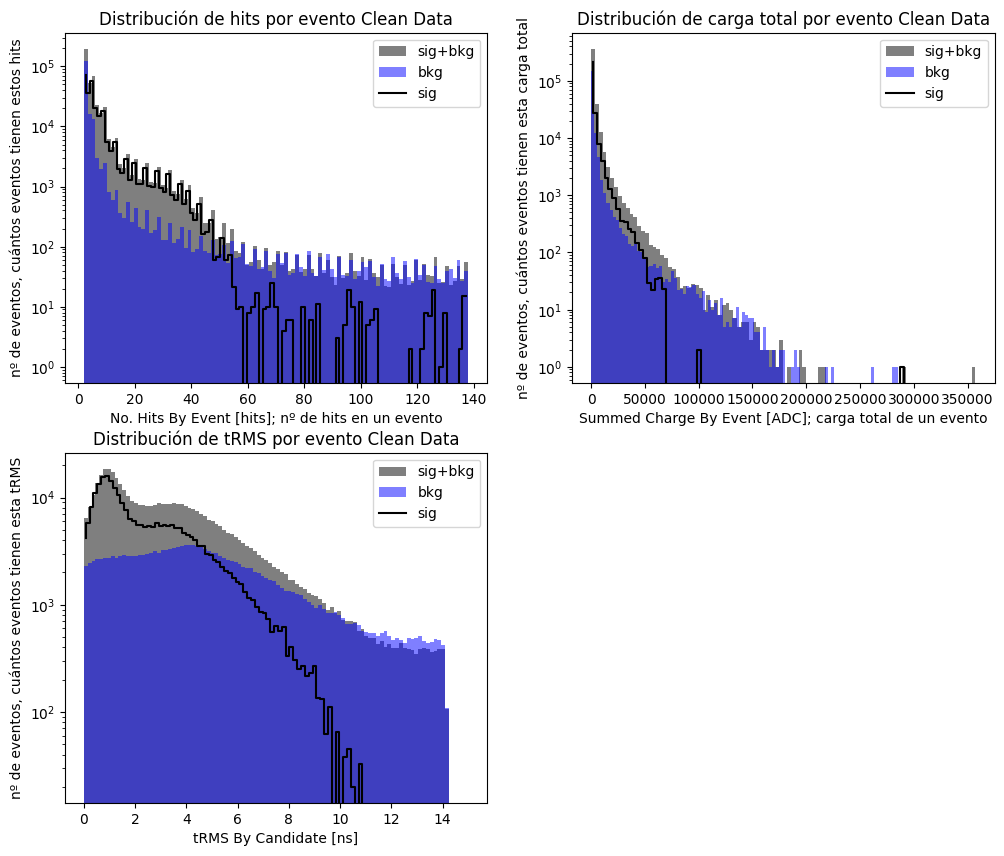

In [21]:
subplot = pltext.canvas(3)

subplot(1)
counts_sig_nhits, edges_sig_nhits, _ = plt.hist(total_nhits_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_nhits, edges_bkg_nhits, _ = plt.hist(total_nhits_by_event_bkg_clean, 100, histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_nhits = (edges_sig_nhits[:-1] + edges_sig_nhits [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits, counts_sig_nhits - counts_bkg_nhits, label="sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(2)

counts_sig_charge, edges_sig_charge, _ = plt.hist(total_charge_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_charge, edges_bkg_charge, _ = plt.hist(total_charge_by_event_bkg_clean, 100, histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_charge = (edges_sig_charge[:-1] + edges_sig_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge, counts_sig_charge - counts_bkg_charge, label="sig", color="k") ;

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()


subplot(3)
counts_sig_trms, edges_sig_trms, _ = plt.hist(total_trms_by_event_sig_clean, 100, range=(0,15), histtype="stepfilled", alpha=0.5, label="sig+bkg")
counts_bkg_trms, edges_bkg_trms, _ = plt.hist(total_trms_by_event_bkg_clean, 100, range=(0,15), histtype = "stepfilled" ,alpha=0.5, label="bkg")

bin_centers_trms = (edges_sig_trms[:-1] + edges_sig_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms, counts_sig_trms - counts_bkg_trms, label="sig", color="k") ; #Esto que plotea ya es la resta bin a bin, pero no era que no tenían la misma longitud???
#Este código separa los dos arrays de hist (así después me evito tener que usar weights y es solo hacer una resta)

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
plt.yscale("log")

# CORTES CON MASKS

## Cortes en nhits por evento

In [22]:
#hago los cortes: busco los eventos con número de hits entre 5(10) y 60 hits.
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: una mask
#tengo q hacer dos para los dos límites inferiores que me pidieron

mask_5_bkg = (total_nhits_by_event_bkg_clean > 5) & (total_nhits_by_event_bkg_clean <= 60)
mask_5_sig = (total_nhits_by_event_sig_clean > 5) & (total_nhits_by_event_sig_clean <= 60)  #no puedo usar la misma máscara para los dos porq son series diferentes

mask_10_bkg = (total_nhits_by_event_bkg_clean > 10) & (total_nhits_by_event_bkg_clean <= 60)
mask_10_sig = (total_nhits_by_event_sig_clean > 10) & (total_nhits_by_event_sig_clean <= 60)


total_nhits_by_event_sig_clean_mask_5 = total_nhits_by_event_sig_clean[mask_5_sig]
total_nhits_by_event_bkg_clean_mask_5 = total_nhits_by_event_bkg_clean[mask_5_bkg]

total_nhits_by_event_sig_clean_mask_10 = total_nhits_by_event_sig_clean[mask_10_sig]
total_nhits_by_event_bkg_clean_mask_10 = total_nhits_by_event_bkg_clean[mask_10_bkg]

total_charge_by_event_sig_clean_mask_5 = total_charge_by_event_sig_clean.loc[total_nhits_by_event_sig_clean_mask_5.index]
total_charge_by_event_bkg_clean_mask_5 = total_charge_by_event_bkg_clean.loc[total_nhits_by_event_bkg_clean_mask_5.index]

total_charge_by_event_sig_clean_mask_10 = total_charge_by_event_sig_clean.loc[total_nhits_by_event_sig_clean_mask_10.index]
total_charge_by_event_bkg_clean_mask_10 = total_charge_by_event_bkg_clean.loc[total_nhits_by_event_bkg_clean_mask_10.index]

total_trms_by_event_sig_clean_mask_5 = total_trms_by_event_sig_clean.loc[total_nhits_by_event_sig_clean_mask_5.index]
total_trms_by_event_bkg_clean_mask_5 = total_trms_by_event_bkg_clean.loc[total_nhits_by_event_bkg_clean_mask_5.index]

total_trms_by_event_sig_clean_mask_10 = total_trms_by_event_sig_clean.loc[total_nhits_by_event_sig_clean_mask_10.index]
total_trms_by_event_bkg_clean_mask_10 = total_trms_by_event_bkg_clean.loc[total_nhits_by_event_bkg_clean_mask_10.index]

Text(0.5, 0.92, 'Cuts con masks para nhits')

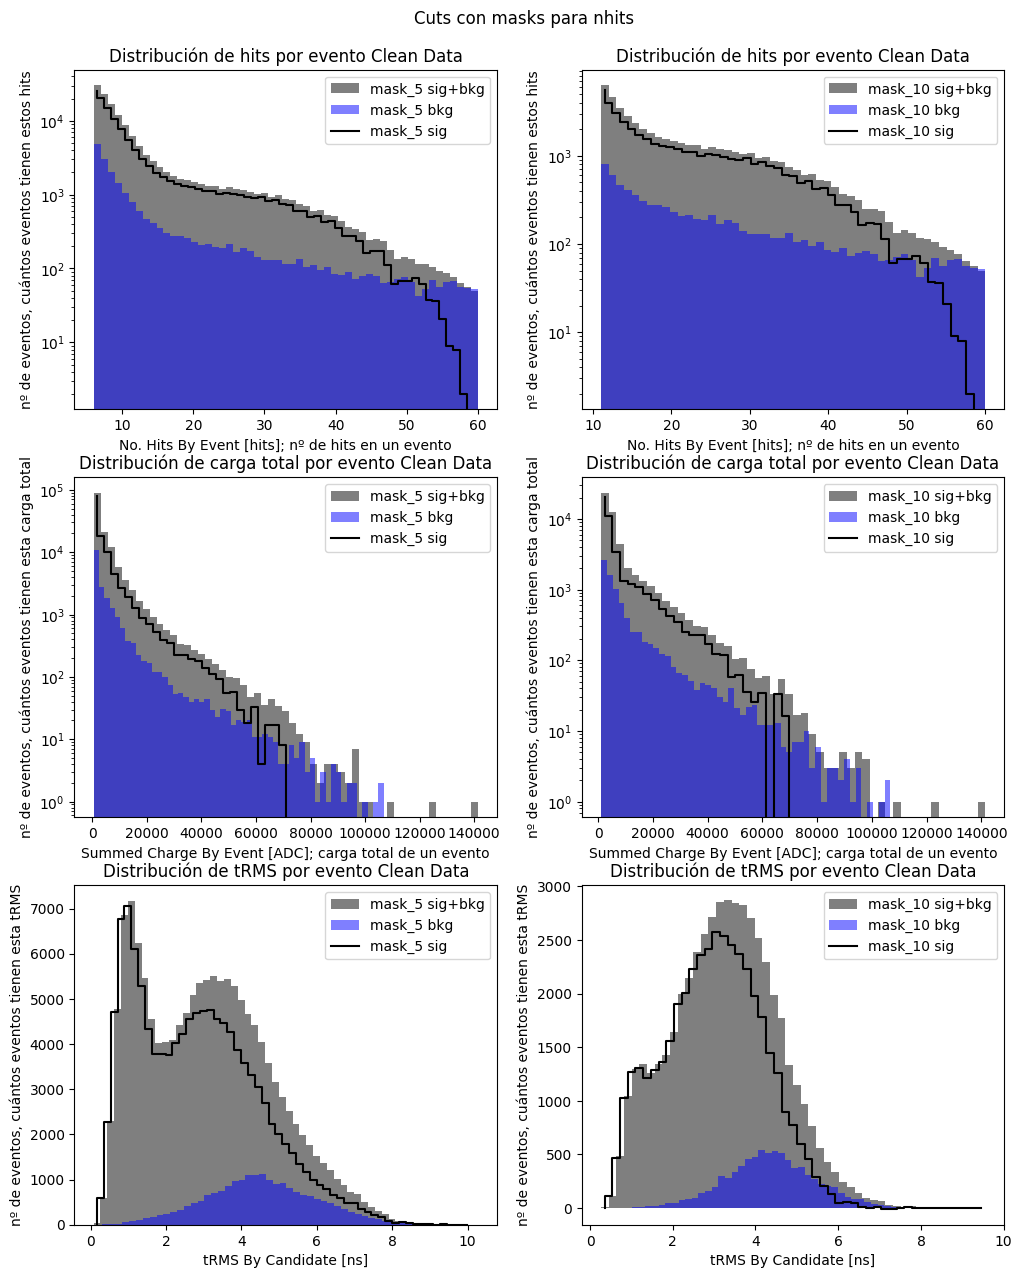

In [44]:
subplot = pltext.canvas(6)

subplot(1)
counts_sig_nhits_mask_5, edges_sig_nhits_mask_5, _ = plt.hist(total_nhits_by_event_sig_clean_mask_5, 55, histtype="stepfilled", alpha=0.5, label="mask_5 sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_5, edges_bkg_nhits_mask_5, _ = plt.hist(total_nhits_by_event_bkg_clean_mask_5, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_5 bkg")

bin_centers_nhits_mask_5 = (edges_sig_nhits_mask_5[:-1] + edges_sig_nhits_mask_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_5, counts_sig_nhits_mask_5 - counts_bkg_nhits_mask_5, label="mask_5 sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(2)
counts_sig_nhits_mask_10, edges_sig_nhits_mask_10, _ = plt.hist(total_nhits_by_event_sig_clean_mask_10, 50, histtype="stepfilled", alpha=0.5, label="mask_10 sig+bkg") #50 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_10, edges_bkg_nhits_mask_10, _ = plt.hist(total_nhits_by_event_bkg_clean_mask_10, 50, histtype = "stepfilled" ,alpha=0.5, label="mask_10 bkg")

bin_centers_nhits_mask_10 = (edges_sig_nhits_mask_10[:-1] + edges_sig_nhits_mask_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_10, counts_sig_nhits_mask_10 - counts_bkg_nhits_mask_10, label="mask_10 sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(3)
counts_sig_charge_mask_5, edges_sig_charge_mask_5, _ = plt.hist(total_charge_by_event_sig_clean_mask_5, 55, histtype="stepfilled", alpha=0.5, label="mask_5 sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_5, edges_bkg_charge_mask_5, _ = plt.hist(total_charge_by_event_bkg_clean_mask_5, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_5 bkg")

bin_centers_charge_mask_5 = (edges_sig_charge_mask_5[:-1] + edges_sig_charge_mask_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_5, counts_sig_charge_mask_5 - counts_bkg_charge_mask_5, label="mask_5 sig", color="k") 

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(4)
counts_sig_charge_mask_10, edges_sig_charge_mask_10, _ = plt.hist(total_charge_by_event_sig_clean_mask_10, 50, histtype="stepfilled", alpha=0.5, label="mask_10 sig+bkg") #50 bins según nhits
counts_bkg_charge_mask_10, edges_bkg_charge_mask_10, _ = plt.hist(total_charge_by_event_bkg_clean_mask_10, 50, histtype = "stepfilled" ,alpha=0.5, label="mask_10 bkg")

bin_centers_charge_mask_10 = (edges_sig_charge_mask_10[:-1] + edges_sig_charge_mask_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_10, counts_sig_charge_mask_10 - counts_bkg_charge_mask_10, label="mask_10 sig", color="k") 

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()

subplot(5)#para trms
counts_sig_trms_mask_5, edges_sig_trms_mask_5, _ = plt.hist(total_trms_by_event_sig_clean_mask_5, 55, histtype="stepfilled", alpha=0.5, label="mask_5 sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_5, edges_bkg_trms_mask_5, _ = plt.hist(total_trms_by_event_bkg_clean_mask_5, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_5 bkg")

bin_centers_trms_mask_5 = (edges_sig_trms_mask_5[:-1] + edges_sig_trms_mask_5 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_5, counts_sig_trms_mask_5 - counts_bkg_trms_mask_5, label="mask_5 sig", color="k") 

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
#plt.yscale("log")

subplot(6)
counts_sig_trms_mask_10, edges_sig_trms_mask_10, _ = plt.hist(total_trms_by_event_sig_clean_mask_10, 50, histtype="stepfilled", alpha=0.5, label="mask_10 sig+bkg") #50 bins según nhits
counts_bkg_trms_mask_10, edges_bkg_trms_mask_10, _ = plt.hist(total_trms_by_event_bkg_clean_mask_10, 50, histtype = "stepfilled" ,alpha=0.5, label="mask_10 bkg")

bin_centers_trms_mask_10 = (edges_sig_trms_mask_10[:-1] + edges_sig_trms_mask_10 [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_10, counts_sig_trms_mask_10 - counts_bkg_trms_mask_10, label="mask_10 sig", color="k") 
plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
#plt.yscale("log")

plt.suptitle("Cuts con masks para nhits", y=0.92)


## Cortes en carga total por evento

In [57]:
#hago los cortes: busco los eventos con carga entre 0 y 100000 [ADC].
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: una mask
#tengo q hacer dos para los dos límites inferiores que me pidieron

mask_charge_bkg = (total_charge_by_event_bkg_clean > 0) & (total_charge_by_event_bkg_clean <= 100000)
mask_charge_sig = (total_charge_by_event_sig_clean > 0) & (total_charge_by_event_sig_clean <= 100000)  #no puedo usar la misma máscara para los dos porq son series diferentes

total_charge_by_event_sig_clean_mask_charge = total_charge_by_event_sig_clean[mask_charge_sig]
total_charge_by_event_bkg_clean_mask_charge = total_charge_by_event_bkg_clean[mask_charge_bkg]

total_nhits_by_event_sig_clean_mask_charge = total_nhits_by_event_sig_clean.loc[total_charge_by_event_sig_clean_mask_charge.index]
total_nhits_by_event_bkg_clean_mask_charge = total_nhits_by_event_bkg_clean.loc[total_charge_by_event_bkg_clean_mask_charge.index]

total_trms_by_event_sig_clean_mask_charge = total_trms_by_event_sig_clean.loc[total_charge_by_event_sig_clean_mask_charge.index]
total_trms_by_event_bkg_clean_mask_charge = total_trms_by_event_bkg_clean.loc[total_charge_by_event_bkg_clean_mask_charge.index]

Text(0.5, 0.96, 'Cuts con masks para charge')

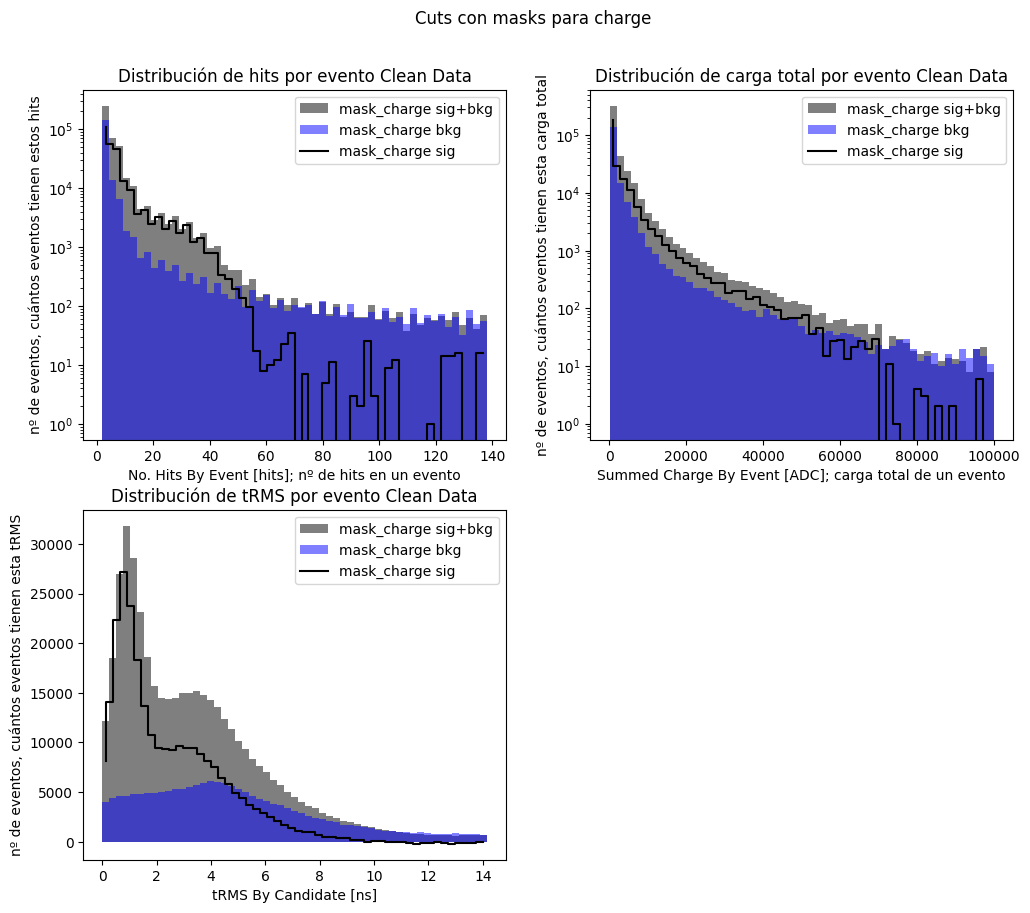

In [62]:
subplot = pltext.canvas(3)

subplot(1)
counts_sig_nhits_mask_charge, edges_sig_nhits_mask_charge, _ = plt.hist(total_nhits_by_event_sig_clean_mask_charge, 55, histtype="stepfilled", alpha=0.5, label="mask_charge sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_charge, edges_bkg_nhits_mask_charge, _ = plt.hist(total_nhits_by_event_bkg_clean_mask_charge, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_charge bkg")

bin_centers_nhits_mask_charge = (edges_sig_nhits_mask_charge[:-1] + edges_sig_nhits_mask_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_charge, counts_sig_nhits_mask_charge - counts_bkg_nhits_mask_charge, label="mask_charge sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()


subplot(2)
counts_sig_charge_mask_charge, edges_sig_charge_mask_charge, _ = plt.hist(total_charge_by_event_sig_clean_mask_charge, 55, histtype="stepfilled", alpha=0.5, label="mask_charge sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_charge, edges_bkg_charge_mask_charge, _ = plt.hist(total_charge_by_event_bkg_clean_mask_charge, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_charge bkg")

bin_centers_charge_mask_charge = (edges_sig_charge_mask_charge[:-1] + edges_sig_charge_mask_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_charge, counts_sig_charge_mask_charge - counts_bkg_charge_mask_charge, label="mask_charge sig", color="k") 

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()
#plt.xlim(0,100000)


subplot(3)#para trms
counts_sig_trms_mask_charge, edges_sig_trms_mask_charge, _ = plt.hist(total_trms_by_event_sig_clean_mask_charge, 55, histtype="stepfilled", alpha=0.5, label="mask_charge sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_charge, edges_bkg_trms_mask_charge, _ = plt.hist(total_trms_by_event_bkg_clean_mask_charge, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_charge bkg")

bin_centers_trms_mask_charge = (edges_sig_trms_mask_charge[:-1] + edges_sig_trms_mask_charge [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_charge, counts_sig_trms_mask_charge - counts_bkg_trms_mask_charge, label="mask_charge sig", color="k") 

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
#plt.yscale("log")


plt.suptitle("Cuts con masks para charge", y=0.96)


## Corte en tRMS

In [59]:
#hago los cortes: busco los eventos con carga entre 0 y 6 [ns].
#busco una serie de valores True/False que te me diga qué filas quiero conservar y cuáles no: una mask
#tengo q hacer dos para los dos límites inferiores que me pidieron

mask_trms_bkg = (total_trms_by_event_bkg_clean > 0) & (total_trms_by_event_bkg_clean <= 6)
mask_trms_sig = (total_trms_by_event_sig_clean > 0) & (total_trms_by_event_sig_clean <= 6)  #no puedo usar la misma máscara para los dos porq son series diferentes

total_trms_by_event_sig_clean_mask_trms = total_trms_by_event_sig_clean[mask_trms_sig]
total_trms_by_event_bkg_clean_mask_trms = total_trms_by_event_bkg_clean[mask_trms_bkg]

total_nhits_by_event_sig_clean_mask_trms = total_nhits_by_event_sig_clean.loc[total_trms_by_event_sig_clean_mask_trms.index]
total_nhits_by_event_bkg_clean_mask_trms = total_nhits_by_event_bkg_clean.loc[total_trms_by_event_bkg_clean_mask_trms.index]

total_charge_by_event_sig_clean_mask_trms = total_charge_by_event_sig_clean.loc[total_trms_by_event_sig_clean_mask_trms.index]
total_charge_by_event_bkg_clean_mask_trms = total_charge_by_event_bkg_clean.loc[total_trms_by_event_bkg_clean_mask_trms.index]

Text(0.5, 0.96, 'Cuts con masks para tRMS')

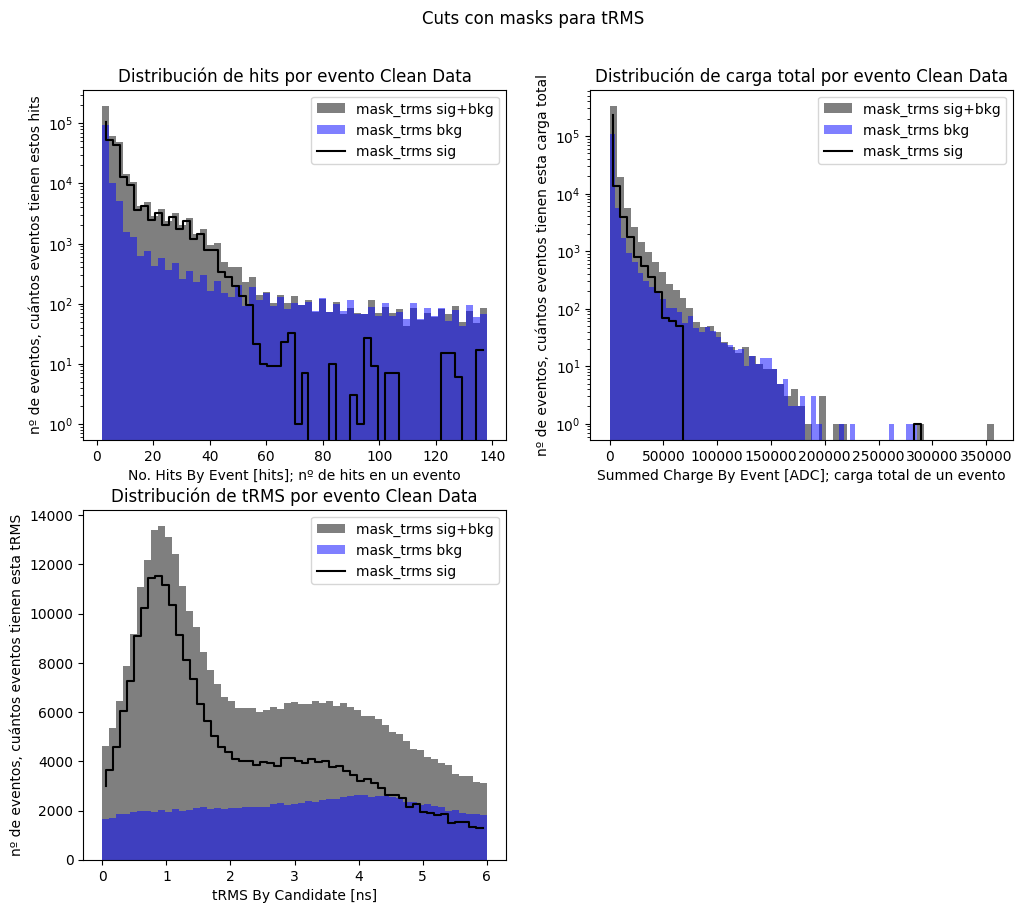

In [60]:
subplot = pltext.canvas(3)

subplot(1)
counts_sig_nhits_mask_trms, edges_sig_nhits_mask_trms, _ = plt.hist(total_nhits_by_event_sig_clean_mask_trms, 55, histtype="stepfilled", alpha=0.5, label="mask_trms sig+bkg") #55 es el máximo sin que haya bins vacíos
counts_bkg_nhits_mask_trms, edges_bkg_nhits_mask_trms, _ = plt.hist(total_nhits_by_event_bkg_clean_mask_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_trms bkg")

bin_centers_nhits_mask_trms = (edges_sig_nhits_mask_trms[:-1] + edges_sig_nhits_mask_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_nhits_mask_trms, counts_sig_nhits_mask_trms - counts_bkg_nhits_mask_trms, label="mask_trms sig", color="k") ;

plt.xlabel("No. Hits By Event [hits]; nº de hits en un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen estos hits")
plt.title("Distribución de hits por evento Clean Data")
plt.yscale("log")
plt.legend()


subplot(2)
counts_sig_charge_mask_trms, edges_sig_charge_mask_trms, _ = plt.hist(total_charge_by_event_sig_clean_mask_trms, 55, histtype="stepfilled", alpha=0.5, label="mask_trms sig+bkg") #55 bins según nhits
counts_bkg_charge_mask_trms, edges_bkg_charge_mask_trms, _ = plt.hist(total_charge_by_event_bkg_clean_mask_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_trms bkg")

bin_centers_charge_mask_trms = (edges_sig_charge_mask_trms[:-1] + edges_sig_charge_mask_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_charge_mask_trms, counts_sig_charge_mask_trms - counts_bkg_charge_mask_trms, label="mask_trms sig", color="k") 

plt.xlabel("Summed Charge By Event [ADC]; carga total de un evento")
plt.ylabel("nº de eventos, cuántos eventos tienen esta carga total")
plt.title("Distribución de carga total por evento Clean Data")
plt.yscale("log")
plt.legend()


subplot(3)#para trms
counts_sig_trms_mask_trms, edges_sig_trms_mask_trms, _ = plt.hist(total_trms_by_event_sig_clean_mask_trms, 55, histtype="stepfilled", alpha=0.5, label="mask_trms sig+bkg") #55 bins según nhits
counts_bkg_trms_mask_trms, edges_bkg_trms_mask_trms, _ = plt.hist(total_trms_by_event_bkg_clean_mask_trms, 55, histtype = "stepfilled" ,alpha=0.5, label="mask_trms bkg")

bin_centers_trms_mask_trms = (edges_sig_trms_mask_trms[:-1] + edges_sig_trms_mask_trms [1:])/2   #divide entre 2 porque calcula el centro del bin
plt.step(bin_centers_trms_mask_trms, counts_sig_trms_mask_trms - counts_bkg_trms_mask_trms, label="mask_trms sig", color="k") 

plt.title("Distribución de tRMS por evento Clean Data")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.legend()
#plt.yscale("log")


plt.suptitle("Cuts con masks para tRMS", y=0.96)


# Corrección a los tiempos calibrados en cada evento

*Trigger*: es el mecanismo q decide cuándo guardar datos (porq al detector le llegan tantos que no se puede guardar todo). En nuestro experimento el trigger es código, pero podría ser también hardware

*Readout window*: intervalo de $t$ en el q el WCTE guarda los hits después del trigger. Diego la definió como 20 [ns]. Entonces, un evento es el conjunto de hits registrados en una readout window, mientra que un candidato es una posible señal física detectada dentro de un evento.

*Dead time*: intervalo de $t$ desupués de registrar una señal en el que el WCTE no puede registrar otra. Diego la definió como 20 [ns]. Al coincidir dead time = readout window, evitamos que los eventos estén solapados, i.e., dos eventos distintos dentro de la misma readout window serían difíciles de separar

In [26]:
#quiero insertar una nueva columna en data_bkg y data_sig. En esta columna irán los tiempos en los que llega el hit respecto del primero de SU evento
#Tendré que hacer una resta del hit_pmt_calibrated_times de los hits respecto del primero, para cada hit en cada evento

hit_pmt_calibrated_times_by_event_bkg = data_by_event_bkg["hit_pmt_calibrated_times"]
hit_pmt_calibrated_times_by_event_sig = data_by_event_sig["hit_pmt_calibrated_times"]

def correct_times(times):
    t0 = times.iloc[0]  #primer hit del evento como ref
    return times - t0

corrected_times_bkg = hit_pmt_calibrated_times_by_event_bkg.apply(correct_times).reset_index(level=0, drop=True)
corrected_times_sig = hit_pmt_calibrated_times_by_event_sig.apply(correct_times).reset_index(level=0, drop=True)
#tengo q usar sí o sí .reset_index(level=0, drop=True) para que corrected_times tenga el mismo índice que data_bkg data_sig, fila por fila
#level=0 elimina el índice del grupo (event_id)
#drop=True no lo convierte en columna, sólo ajusta el índice

data_bkg["pmt_hit_calibrated_times_corrected"] = corrected_times_bkg
data_sig["pmt_hit_calibrated_times_corrected"] = corrected_times_sig



In [27]:
data_bkg

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids,pmt_hit_calibrated_times_corrected
0,0.0,76264.181597,79.0,27.0,2.0,9.0,3.0,0.000000
1,0.0,76273.067467,209.0,118.0,55.0,3.0,18.0,8.885870
2,1.0,209221.084343,103.0,114.0,19.0,13.0,12.0,0.000000
3,1.0,209223.152791,119.0,114.0,19.0,12.0,4.0,2.068448
4,1.0,209233.144440,175.0,114.0,19.0,10.0,10.0,12.060097
...,...,...,...,...,...,...,...,...
1433051,201316.0,459565.065760,111.0,97.0,92.0,1.0,6.0,0.000000
1433052,201316.0,459565.813249,82.0,94.0,11.0,6.0,8.0,0.747489
1433053,201316.0,459568.619830,164.0,32.0,75.0,8.0,9.0,3.554070
1433054,201317.0,461939.606112,372.0,114.0,19.0,3.0,18.0,0.000000


In [28]:
data_sig

,event_id,hit_pmt_calibrated_times,hit_pmt_charges,hit_mpmt_card_ids,hit_mpmt_slot_ids,hit_pmt_channel_ids,hit_pmt_position_ids,pmt_hit_calibrated_times_corrected
0,0.0,53683.787124,117.0,108.0,3.0,14.0,13.0,0.000000
1,0.0,53691.537798,100.0,102.0,22.0,10.0,10.0,7.750674
2,1.0,63479.663380,83.0,12.0,1.0,15.0,5.0,0.000000
3,1.0,63480.392541,133.0,36.0,46.0,13.0,12.0,0.729161
4,1.0,63496.106182,180.0,96.0,8.0,15.0,5.0,16.442802
...,...,...,...,...,...,...,...,...
3361704,455342.0,492800.972765,237.0,78.0,33.0,11.0,11.0,2.572756
3361705,455342.0,492801.767311,123.0,85.0,93.0,4.0,1.0,3.367302
3361706,455342.0,492801.914035,140.0,20.0,81.0,17.0,15.0,3.514026
3361707,455342.0,492802.180405,221.0,100.0,24.0,2.0,0.0,3.780396


Text(0.5, 0.98, 'Comparison mean_times por evento')

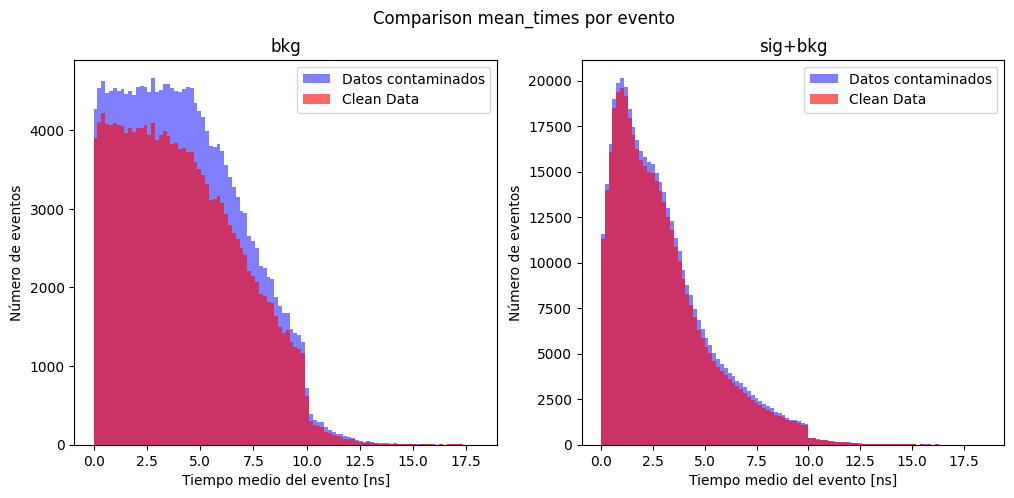

In [29]:
mean_times_by_event_bkg = data_by_event_bkg["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_sig = data_by_event_sig["pmt_hit_calibrated_times_corrected"].mean()

mean_times_by_event_bkg_only_spills = mean_times_by_event_bkg.drop(indices_saturating_bkg)  #ahora quito los eventos contaminados
mean_times_by_event_bkg_clean = mean_times_by_event_bkg_only_spills.drop(combined_indices_bkg)

mean_times_by_event_sig_only_spills = mean_times_by_event_sig.drop(indices_saturating_sig)
mean_times_by_event_sig_clean = mean_times_by_event_sig_only_spills.drop(spill_3.index)

subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_event_bkg, 100, color="b", label="Datos contaminados", alpha=0.5)
#plt.hist(mean_times_by_event_bkg_only_spills, bins=100, color="green",label="Only spills", alpha=0.7)
plt.hist(mean_times_by_event_bkg_clean, bins=100, color="r",label="Clean Data", alpha=0.6)
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.title("bkg")
plt.legend()

subplot(2)
plt.hist(mean_times_by_event_sig, 100, color="b", label="Datos contaminados",alpha=0.5)
#plt.hist(mean_times_by_event_sig_only_spills, bins=100, color="green",label="Only spills", alpha=0.7)
plt.hist(mean_times_by_event_sig_clean, bins=100, color="r",label="Clean Data", alpha=0.6)
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.title("sig+bkg")
plt.legend()

plt.suptitle("Comparison mean_times por evento")

In [30]:
#hacemos lo mismo pero SÓLO para los eventos que pasan el cut de mask_5 y mask_10

events_bkg_mask_5 = total_nhits_by_event_bkg_clean[mask_5_bkg].index    #candidates que pasan el cut, los seleccionamos con el ínidce
events_bkg_mask_10 = total_nhits_by_event_bkg_clean[mask_10_bkg].index
events_sig_mask_5 = total_nhits_by_event_sig_clean[mask_5_sig].index
events_sig_mask_10 = total_nhits_by_event_sig_clean[mask_10_sig].index


data_bkg_mask_5 = data_bkg[data_bkg["event_id"].isin(events_bkg_mask_5)]    # .isin() devuelve una serie de valores True/False 
data_bkg_mask_10 = data_bkg[data_bkg["event_id"].isin(events_bkg_mask_10)]  #data_bkg[ lista de isin] es la serie en la que las filas es el resultado True
data_sig_mask_5 = data_sig[data_sig["event_id"].isin(events_sig_mask_5)]
data_sig_mask_10 = data_sig[data_sig["event_id"].isin(events_sig_mask_10)]

data_bkg_by_event_mask_5 = data_bkg_mask_5.groupby("event_id")  #agrupo de nuevo los hits en sus eventos
data_bkg_by_event_mask_10 = data_bkg_mask_10.groupby("event_id")
data_sig_by_event_mask_5 = data_sig_mask_5.groupby("event_id")
data_sig_by_event_mask_10 = data_sig_mask_10.groupby("event_id")


mean_times_by_event_bkg_mask_5 = data_bkg_by_event_mask_5["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_bkg_mask_10 = data_bkg_by_event_mask_10["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_sig_mask_5 = data_sig_by_event_mask_5["pmt_hit_calibrated_times_corrected"].mean()
mean_times_by_event_sig_mask_10 = data_sig_by_event_mask_10["pmt_hit_calibrated_times_corrected"].mean()


Text(0.5, 0.98, 'Comparison mean_times por evento con cuts en nhits')

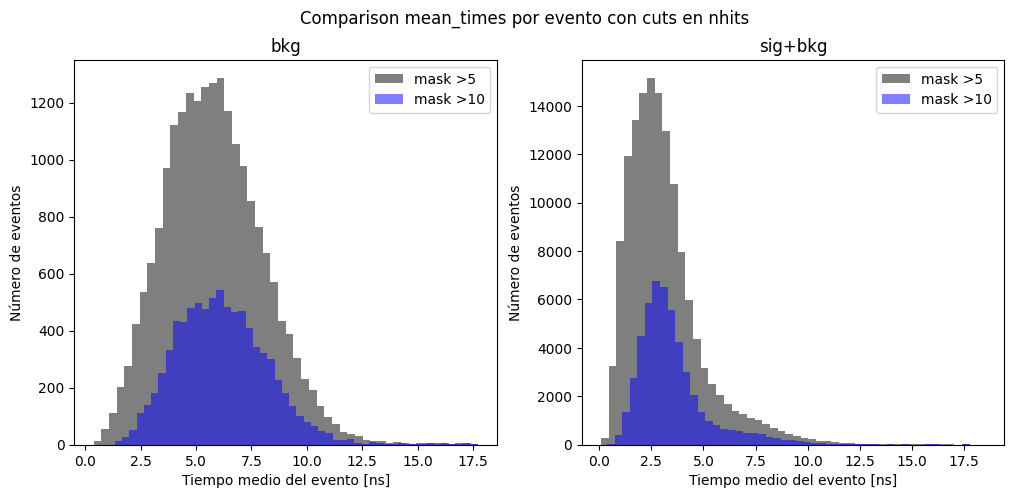

In [31]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist(mean_times_by_event_bkg_mask_5, bins=50, alpha=0.5, label="mask >5")
plt.hist(mean_times_by_event_bkg_mask_10, bins=50, alpha=0.5, label="mask >10")
plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("bkg")

subplot(2)
plt.hist(mean_times_by_event_sig_mask_5, bins=50, alpha=0.5, label="mask >5")
plt.hist(mean_times_by_event_sig_mask_10, bins=50, alpha=0.5, label="mask >10")

plt.xlabel("Tiempo medio del evento [ns]")
plt.ylabel("Número de eventos")
plt.legend()
plt.title("sig+bkg")
plt.suptitle("Comparison mean_times por evento con cuts en nhits")

# Scatters

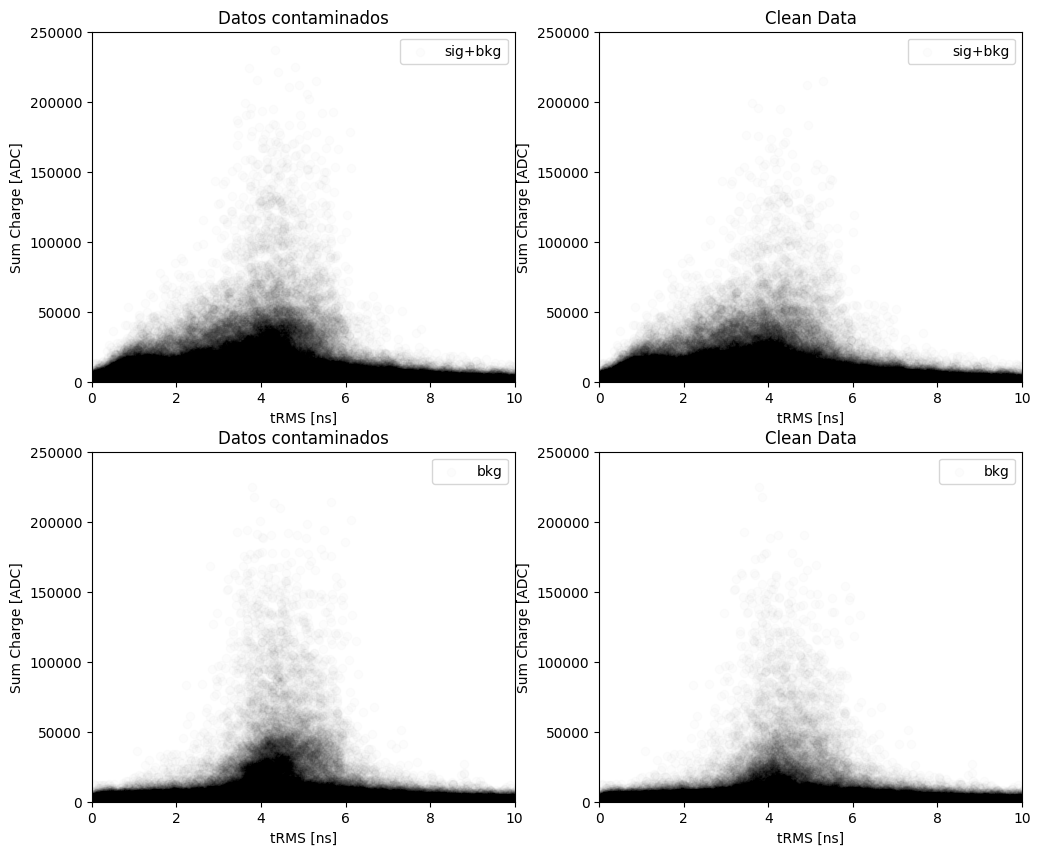

In [32]:
subplot = pltext.canvas(4)

subplot(1)
plt.scatter(total_trms_by_event_sig, total_charge_by_event_sig, alpha=0.01, label="sig+bkg")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Datos contaminados")    #Datos con spills y valores saturantes
plt.legend()

subplot(2)
plt.scatter(total_trms_by_event_sig_clean, total_charge_by_event_sig_clean, alpha=0.01, label="sig+bkg")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Clean Data")
plt.legend()

subplot(3)
plt.scatter(total_trms_by_event_bkg, total_charge_by_event_bkg, alpha=0.01, label="bkg");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Datos contaminados")
plt.legend()

subplot(4)
plt.scatter(total_trms_by_event_bkg_clean, total_charge_by_event_bkg_clean, alpha=0.01, label="bkg");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Clean Data")
plt.legend()

#antes calculé sig4, que es la señal pura bin a bin en el histograma, pero no evento a evento. Como no tengo su event_id no puedo scatterear sig4 porque no es un dataset


En estos scatters se representa un evento como un punto (tRMS, Q_tot). Tenemos muchísimos eventos con carga baja, y en 4 [ns] está la señal (acumulación con cargas más altas).

Text(0.5, 1.0, 'Clean Data, bkg')

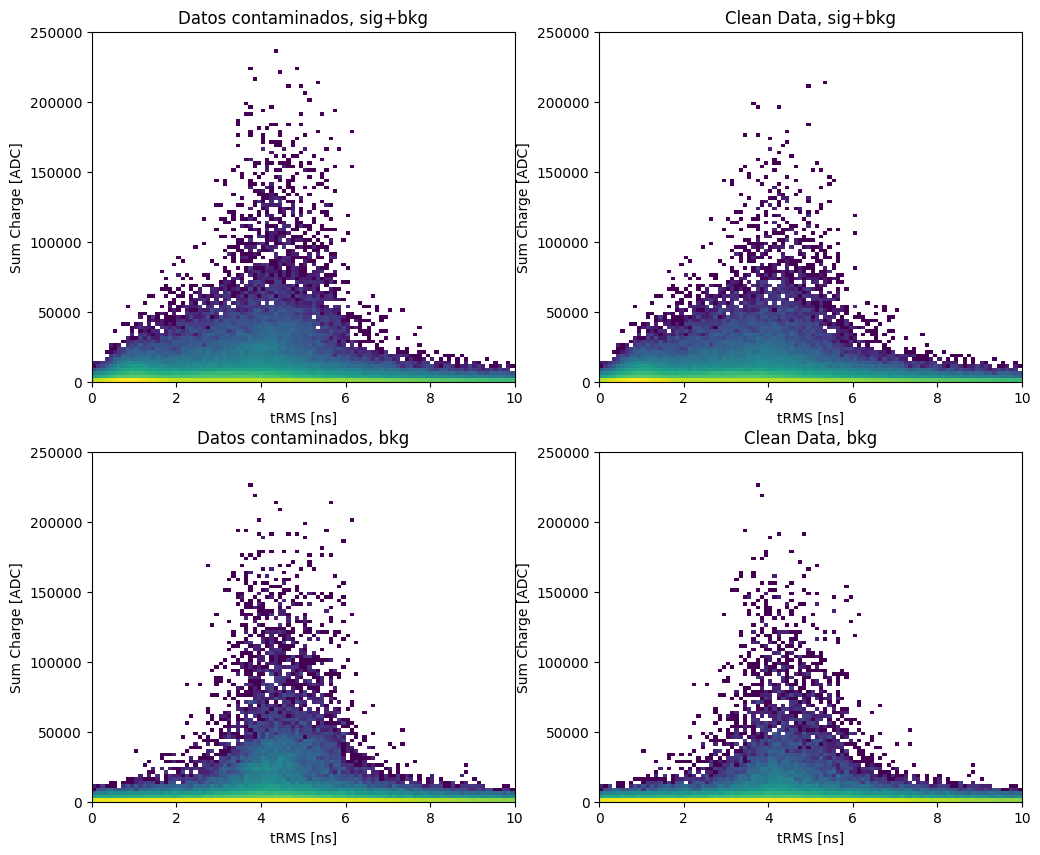

In [33]:
subplot = pltext.canvas(4)

subplot(1)
plt.hist2d(total_trms_by_event_sig, total_charge_by_event_sig, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Datos contaminados, sig+bkg")

subplot(2)
plt.hist2d(total_trms_by_event_sig_clean, total_charge_by_event_sig_clean, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Clean Data, sig+bkg")

subplot(3)
plt.hist2d(total_trms_by_event_bkg, total_charge_by_event_bkg, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Datos contaminados, bkg")

subplot(4)
plt.hist2d(total_trms_by_event_bkg_clean, total_charge_by_event_bkg_clean, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Clean Data, bkg")

#antes calculé sig4, que es la señal pura bin a bin en el histograma, pero no evento a evento. Como no tengo su event_id no puedo scatterear sig4 porque no es un dataset


Text(0.5, 0, 'Summed Charge By Event [ADC]')

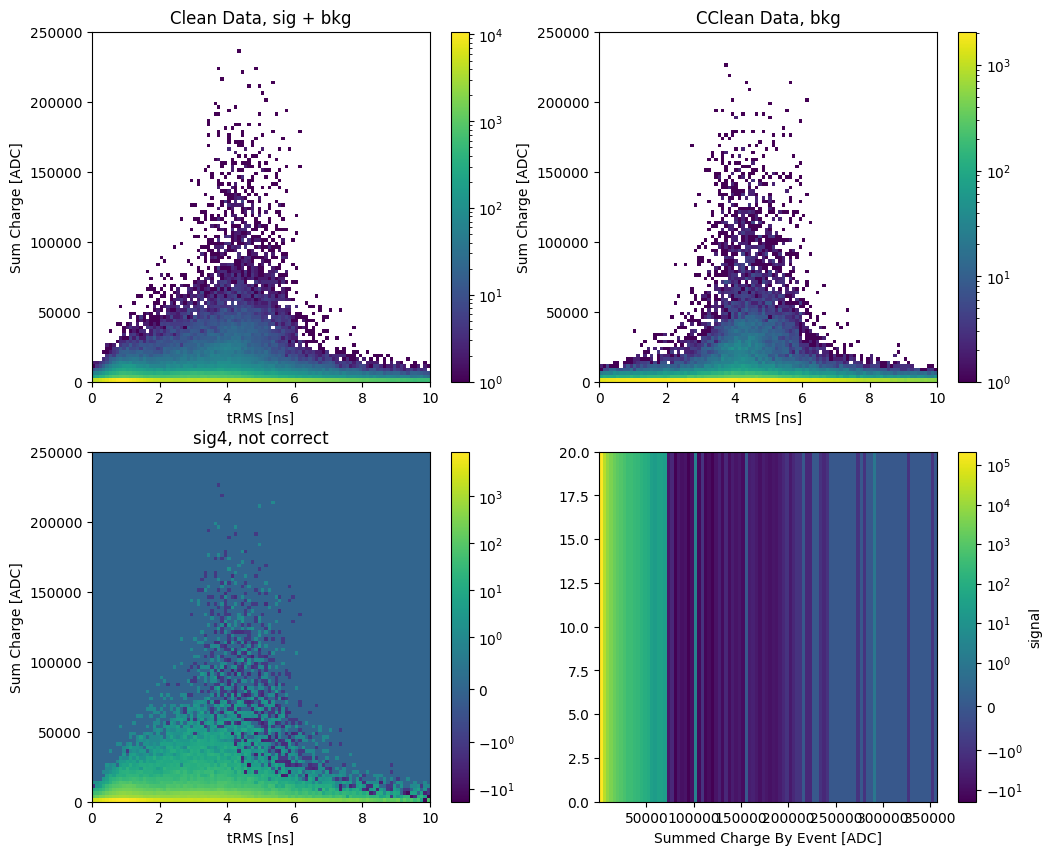

In [34]:
from matplotlib.colors import SymLogNorm

all_trms_2d = np.concatenate([total_trms_by_event_sig_clean, total_trms_by_event_bkg_clean])
all_charge_2d = np.concatenate([total_charge_by_event_sig_clean, total_charge_by_event_bkg_clean])
all_weights_2d = np.concatenate([np.ones_like(total_trms_by_event_sig_clean), -1*np.ones_like(total_trms_by_event_bkg_clean)])

subplot = pltext.canvas(4)

subplot(1)
plt.hist2d(total_trms_by_event_sig, total_charge_by_event_sig, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("Clean Data, sig + bkg")
plt.colorbar()

subplot(2)
plt.hist2d(total_trms_by_event_bkg, total_charge_by_event_bkg, (100, 100), range=((0, 10), (0, 250e3)), norm="log")
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("CClean Data, bkg")
plt.colorbar()

subplot(3)  #para usar weights no puedo usar plt.hist2d, uso np.histogram2d()

bins_trms = np.linspace(0, 10, 101)     #creo 100 bins de 0.1 [ns] cada uno
bins_charge = np.linspace(0, 250e3, 101)    #creo 100 bins de 2500 [ADC] cada uno

H, xedges, yedges = np.histogram2d(all_trms_2d, all_charge_2d, bins=[bins_trms, bins_charge], weights=all_weights_2d)
#toma cada punto de all_trms_2d y all_charge_2d
#determina en qué bin cae según bins_tRMS y bins_charge
#en vez de sumar +1 a esa celda, suma el peso correspondiente de all_weights_2d
#resultado: crea la matriz 100x100:  H[i,j] = (eventos_sig+bkg_en_bin) - (eventos_bkg_en_bin)

plt.pcolormesh(xedges, yedges, H.T,norm=plt.matplotlib.colors.SymLogNorm(linthresh=1, linscale=1))
#dibuja malla de colores donde cada bin tiene el color correspondiente a su valor en H.T (traspuesta xq pcolormesh devuelve primero Y y leugo X)
#SymLogNorm para valores positivos y negativos, linthresh=1 : umbral para la región lineal, linscale=1 : escala de la región lineal

plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3)
plt.xlim(0, 10)
plt.title("sig4, not correct")
plt.colorbar()

subplot(4)      #NOOO
signal = counts_sig_charge - counts_bkg_charge

H = np.tile(signal, (20,1))

yedges = np.arange(21)

plt.pcolormesh(
    edges_sig_charge,
    yedges,
    H,
    norm=SymLogNorm(linthresh=1, linscale=1)
)

plt.colorbar(label="signal")
plt.xlabel("Summed Charge By Event [ADC]")



# Automatización spills(?)

Pois así de primeiras, a maneira que se me ocorre a min é que ti podes percorrer todo o teu DataFrame de candidates e eliminar aqueles que teñan más de x hits, onde x é un threshold que ti estimas.

Por exemplo, do primeiro plot que envías vemos claramente que a liña basal está en torno a 7-8 (podes calcular a media de hits por candidate), mentres que os que sobresalen chegan a 40 ou así. Isto nos di que queremos quedarnos con aqueles candidates que teñen un número de hits dentro dos límites que poñemos nós (7-8 ou a media, ou media ponderada)

#df_filtrado = df[df["hits"] <= threshold] Sintaxis para esto


In [35]:
#para todos los candidates

clean_series_0 = total_nhits_by_event_bkg_spills

filtered_series_threshold20 = clean_series_0[clean_series_0 <= 20]
filtered_series_threshold7 = clean_series_0[clean_series_0 <= 7]

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(filtered_series_threshold20.index, filtered_series_threshold20.values, s=0.2, alpha=0.03)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background con threshold 20")

subplot(2)
plt.scatter(filtered_series_threshold7.index, filtered_series_threshold7.values, s=0.2, alpha=0.03)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.title("background con threshold 7")



NameError: name 'total_nhits_by_event_bkg_spills' is not defined

Text(0.5, 0.98, 'threshold 7')

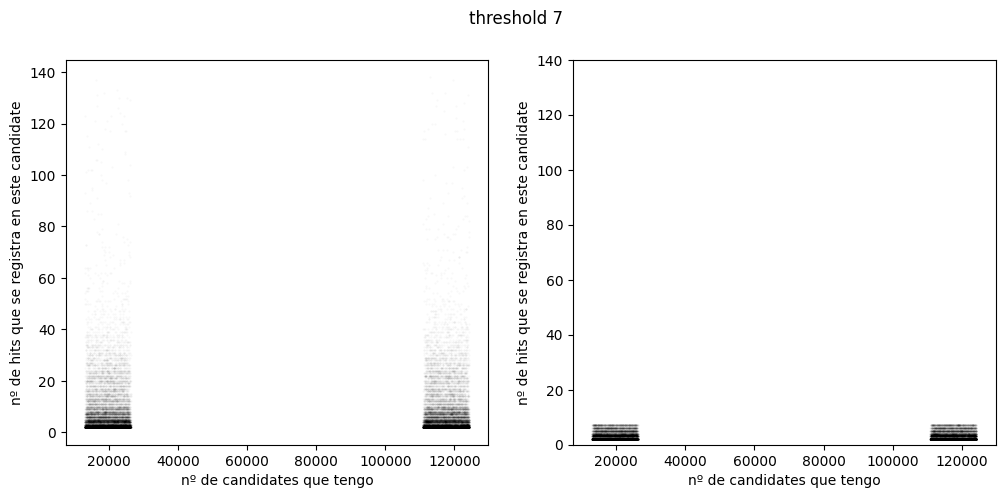

In [ ]:
#para las regiones entre líneas rojas

#series que hay que quitar
clean_series_1 = clean_series_0[(clean_series_0.index >= x_min_s1) & (clean_series_0.index <= x_max_s1)]
clean_series_2 = clean_series_0[(clean_series_0.index >= x_min_s2) & (clean_series_0.index <= x_max_s2)]

#hay que concatenar sus índices, NO SUMAR

clean_series_combined = pd.concat([clean_series_1, clean_series_2])
#combined_indices = pd.concat([clean_series_1, clean_series_2]).index

filtered_series_red_lines_threshold7 = clean_series_combined[clean_series_combined <= 7]

subplot = pltext.canvas(2)

subplot(1)
plt.scatter(clean_series_combined.index, clean_series_combined.values, s=0.2, alpha=0.03)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")

subplot(2)
plt.scatter(filtered_series_red_lines_threshold7.index, filtered_series_red_lines_threshold7.values, s=0.2, alpha=0.03)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits que se registra en este candidate")
plt.ylim(0,140)

plt.suptitle("threshold 7")

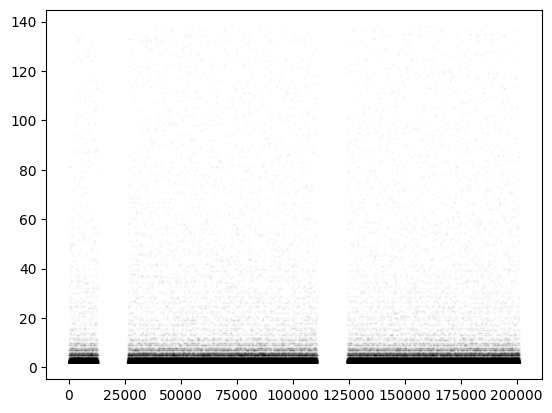

In [ ]:
serie_de_las_barras = clean_series_combined.index

serie_total_menos_barras = clean_series_0.drop(serie_de_las_barras)
plt.scatter(serie_total_menos_barras.index, serie_total_menos_barras.values, s=0.2, alpha=0.03)

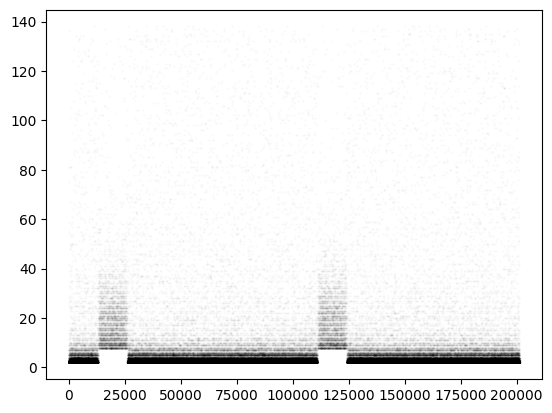

In [ ]:
combined_indices_thershold7 = filtered_series_red_lines_threshold7.index
clean_series_total_threshold7 = clean_series_0.drop(combined_indices_thershold7)

plt.scatter(clean_series_total_threshold7.index, clean_series_total_threshold7.values, s=0.2, alpha=0.03)

# Intentos resta de bines

Los argumentos de hist son:

matplotlib.pyplot.hist(x, bins=None, *, range=None, density=False, weights=None, cumulative=False, bottom=None, histtype='bar', align='mid', orientation='vertical', rwidth=None, log=False, color=None, label=None, stacked=False, data=None, **kwargs)

* weights(n,) array-like or None, default: None
An array of weights, of the same shape as x. Each value in x only contributes its associated weight towards the bin count (instead of 1). If density is True, the weights are normalized, so that the integral of the density over the range remains 1.

Para restar los histogramas lo más fácil es definir sus pesos (weights) como +1 para sig y como -1 para bkg. Con n.ones_like() creo un array de unos (1) con la misma longitud que los datos de la serie que le ponga. Lógicamente debo escalar a la longitud de cada serie normalizando, y lo hago para el bkg con -normalization

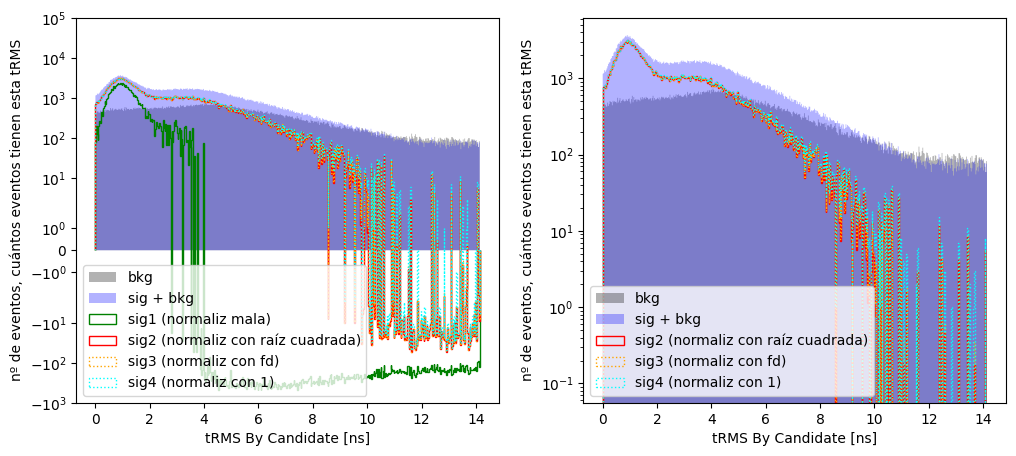

In [ ]:
#total_trms_by_event_pure_sig = total_trms_by_event_sig_clean - total_trms_by_event_bkg_clean  Esto no funciona porque son series de longitudes diferentes

#FACTOR DE NORMALIZACIÓN: para escalar la longitud relativa de ambas series

normalization_trms = len(total_trms_by_event_sig_clean) / len(total_trms_by_event_bkg_clean)    #2.5170285978660036, sig+bkg tiene 2.52 veces más eventos totales que bkg

weights_sig_trms = np.ones_like(total_trms_by_event_sig_clean)

weights_bkg_trms_1 = - normalization_trms*np.ones_like(total_trms_by_event_bkg_clean)   #asume que la densidad de bkg es propto al tamaño de sig+bkg, SOBREESTIMA bkg
weights_bkg_trms_2 = -  1.0353423013098895*np.ones_like(total_trms_by_event_bkg_clean)   #sqrt
weights_bkg_trms_3 = -  1.033093985496943*np.ones_like(total_trms_by_event_bkg_clean)   #fd
weights_bkg_trms_4 = -  1*np.ones_like(total_trms_by_event_bkg_clean)   #bkg = sig+bkg perfecto

all_trms = np.concatenate([total_trms_by_event_sig_clean, total_trms_by_event_bkg_clean])   #lo junto todo

all_weights_trms_1 = np.concatenate([weights_sig_trms, weights_bkg_trms_1])
all_weights_trms_2 = np.concatenate([weights_sig_trms, weights_bkg_trms_2])
all_weights_trms_3 = np.concatenate([weights_sig_trms, weights_bkg_trms_3])
all_weights_trms_4 = np.concatenate([weights_sig_trms, weights_bkg_trms_4])

subplot = pltext.canvas(2)

subplot(1)
plt.hist(total_trms_by_event_bkg_clean, 500, histtype="stepfilled", alpha=0.3, label="bkg")
plt.hist(total_trms_by_event_sig_clean, 500, histtype="stepfilled", alpha=0.3, label="sig + bkg")
plt.hist(all_trms, 500, weights=all_weights_trms_1, histtype="step", color="green", alpha=1, label="sig1 (normaliz mala)")
plt.hist(all_trms, 500, weights=all_weights_trms_2, histtype="step", color="red", alpha=1, label="sig2 (normaliz con raíz cuadrada)")    #este creo que valdría
plt.hist(all_trms, 500, weights=all_weights_trms_3, histtype="step", color="orange", alpha=1, linestyle=":", label="sig3 (normaliz con fd)")   #este creo que tb
plt.hist(all_trms, 500, weights=all_weights_trms_4, histtype="step", color="cyan", alpha=1, linestyle=":", label="sig4 (normaliz con 1)")   #este creo que tb
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.yscale("symlog")
plt.ylim(-1e3, 1e5)
plt.legend()

subplot(2)
plt.hist(total_trms_by_event_bkg_clean, 500, histtype="stepfilled", alpha=0.3, label="bkg")
plt.hist(total_trms_by_event_sig_clean, 500, histtype="stepfilled", alpha=0.3, label="sig + bkg")
#plt.hist(all_trms, 500, weights=all_weights_trms_1, histtype="step", color="green", alpha=1, label="sig1 (normaliz mala)")
plt.hist(all_trms, 500, weights=all_weights_trms_2, histtype="step", color="red", alpha=1, label="sig2 (normaliz con raíz cuadrada)")    #este creo que valdría
plt.hist(all_trms, 500, weights=all_weights_trms_3, histtype="step", color="orange", alpha=1, linestyle=":", label="sig3 (normaliz con fd)")   #este creo que tb
plt.hist(all_trms, 500, weights=all_weights_trms_4, histtype="step", color="cyan", alpha=1, linestyle=":", label="sig4 (normaliz con 1)")   #este creo que tb
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.yscale("log")
plt.legend()


In [ ]:
normalization_trms

2.5170285978660036

In [ ]:
#NORMALIZACIÓN PARA LOS WEIGHTS en la región de solo fondo

bins_sqrt = np.linspace(0, 15, 415)  #415 (sqrt{n}) bins de 0 a 15 ns
hist_bkg_sqrt, _ = np.histogram(total_trms_by_event_bkg_clean, bins=bins_sqrt)    #conteos, bordes = np.histogram(datos, bins), los bordes no nos interesan y ponemos _
hist_sig_sqrt, _ = np.histogram(total_trms_by_event_sig_clean, bins=bins_sqrt)

mask_only_bkg_sqrt = bins_sqrt[:-1] > 8     #mask para bins talq ue tRMS>8 [ns] (solo bkg)
#bins[:-1] límites inferior del bin ; > 8 crea un array booleano: True para bins > 8, False para bins ≤ 8
#print(mask_only_bkg_sqrtn)

only_bkg_bkg_sqrt = np.sum(hist_bkg_sqrt[mask_only_bkg_sqrt])  #usamos la región de solo fondo para normalizar
only_bkg_sig_sqrt = np.sum(hist_sig_sqrt[mask_only_bkg_sqrt])
normalization_sqrt = only_bkg_sig_sqrt / only_bkg_bkg_sqrt

#__________________________________________________________________________________
bins_fd = np.linspace(0, 15, 100)  #100 (fd) bins de 0 a 15 ns
hist_bkg_fd, _ = np.histogram(total_trms_by_event_bkg_clean, bins=bins_fd)
hist_sig_fd, _ = np.histogram(total_trms_by_event_sig_clean, bins=bins_fd)

mask_only_bkg_fd = bins_fd[:-1] > 8

only_bkg_bkg_fd = np.sum(hist_bkg_fd[mask_only_bkg_fd])
only_bkg_sig_fd = np.sum(hist_sig_fd[mask_only_bkg_fd])
normalization_fd = only_bkg_sig_fd / only_bkg_bkg_fd


print(f"Factor de normalización por regla de raíz cuadrada: {normalization_sqrt}")
print(f"Factor de normalización por regla de Freedman-Diaconis: {normalization_fd}")

Factor de normalización por regla de raíz cuadrada: 1.0353423013098895
Factor de normalización por regla de Freedman-Diaconis: 1.033093985496943


In [ ]:
#para saber el número de bins

#Regla de la raíz cuadrada
n_events_min = min(len(total_trms_by_event_bkg_clean), len(total_trms_by_event_sig_clean))  #usamos el mínimo xq sig+bkg y bkg deben usar los mismos bins para ser comparables
n_bins_sqrt_rule = int(np.sqrt(n_events_min))

#Refla de Freedman-Diaconis, fórmula de google
h_bkg = 2 * (np.percentile(total_trms_by_event_bkg_clean, 75) - np.percentile(total_trms_by_event_bkg_clean, 25)) * len(total_trms_by_event_bkg_clean)**(-1/3)
h_sig = 2 * (np.percentile(total_trms_by_event_sig_clean, 75) - np.percentile(total_trms_by_event_sig_clean, 25)) * len(total_trms_by_event_sig_clean)**(-1/3)

n_bins_bkg = int((total_trms_by_event_bkg_clean.max() - total_trms_by_event_bkg_clean.min()) / h_bkg)
n_bins_sig = int((total_trms_by_event_sig_clean.max() - total_trms_by_event_sig_clean.min()) / h_sig)

n_bins_fd_rule = min(n_bins_bkg, n_bins_sig) #esto no sé si es muy correcto

print(f"nº de bins por regla de raíz cuadrada: {n_bins_sqrt_rule}")
print(f"nº de bins por regla de Freedman-Diaconis: {n_bins_fd_rule}")

nº de bins por regla de raíz cuadrada: 415
nº de bins por regla de Freedman-Diaconis: 91


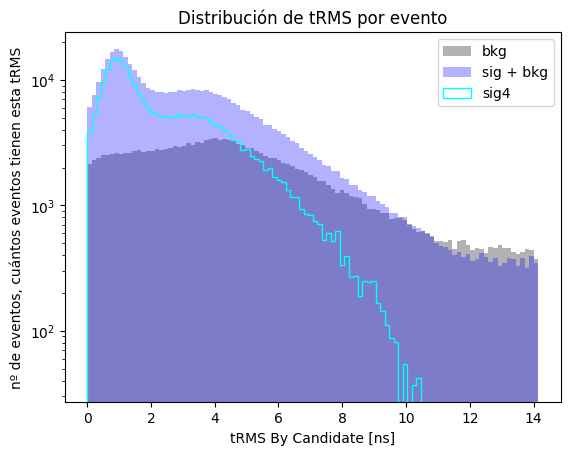

In [ ]:
plt.hist(total_trms_by_event_bkg_clean, 100, histtype="stepfilled", alpha=0.3, label="bkg")
plt.hist(total_trms_by_event_sig_clean, 100, histtype="stepfilled", alpha=0.3, label="sig + bkg")
plt.hist(all_trms, 100, weights=all_weights_trms_4, histtype="step", color="cyan", alpha=1, label="sig4")
#plt.step(bin_centers, counts_sig - counts_bkg, label="Resta buena con counts")
plt.xlabel("tRMS By Candidate [ns]")
plt.ylabel("nº de eventos, cuántos eventos tienen esta tRMS")
plt.title("Distribución de tRMS por evento")
plt.yscale("log")
plt.legend()

# Esto ya es código de Diego

In [ ]:
#data_bkg = data_bkg[(data_bkg["event_id"].values < 300e3) & (data_bkg["event_id"].values > 150e3)]
#data_sig = data_sig[(data_sig["event_id"].values < 0.4e6) & (data_sig["event_id"].values > 0)]

In [ ]:
data_by_event_bkg=data_bkg.groupby("event_id")
total_charge_by_event_bkg=data_by_event_bkg["hit_pmt_charges"].sum() #data_by_event["hit_pmt_charges"] con los [] seleccionamos
total_nhits_by_event_bkg = data_by_event_bkg.size()
total_trms_by_event_bkg  = data_by_event_bkg["hit_pmt_calibrated_times"].std()

data_by_event_sig=data_sig.groupby("event_id")
total_charge_by_event_sig=data_by_event_sig["hit_pmt_charges"].sum()
total_nhits_by_event_sig = data_by_event_sig.size()
total_trms_by_event_sig  = data_by_event_sig["hit_pmt_calibrated_times"].std()
#######################################################################
# #la columna hit_pmt_charges de cada grupo y luego sumamos sus valores
# print(total_charge_by_event)

# #==============CHATTY===========================================
# # Busco los 30 eventos con más hits
# top_30_charge=total_charge_by_event.nlargest(30) #crea una serie con los 30 valores más grandes de total_charge_by_event

# print("="*60)
# print("TOP 30 EVENTOS CON MÁS CARGA TOTAL")
# print("="*60)

# # Convertir a DataFrame con ranking desde 1
# top_30_df = top_30_charge.reset_index()
# top_30_df.columns = ['event_id', 'carga total']
# top_30_df.index = top_30_df.index + 1
# top_30_df.index.name = 'ranking'

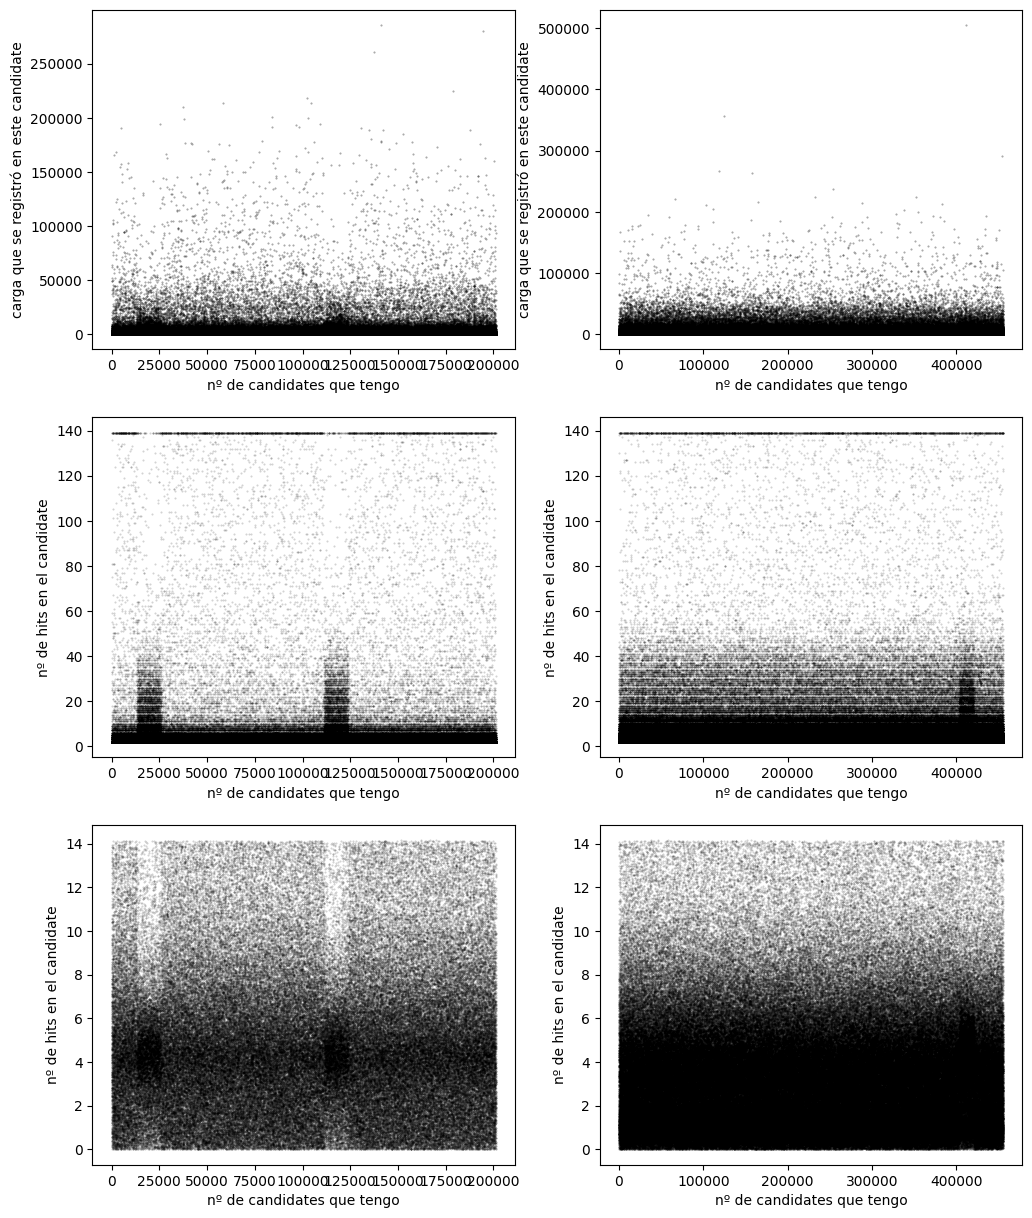

In [ ]:
subplot = pltext.canvas(6)  #ME DESAPARECEN LOS SPILLS??

subplot(1)
plt.scatter(total_charge_by_event_bkg.index, total_charge_by_event_bkg.values, s=0.2, alpha=0.4)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registró en este candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
#plt.ylim(0, 50e3); 

subplot(2)
plt.scatter(total_charge_by_event_sig.index, total_charge_by_event_sig.values, s=0.2, alpha=0.4)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("carga que se registró en este candidate")
#plt.ylim(0, 50e3);

subplot(3)
plt.scatter(total_nhits_by_event_bkg.index, total_nhits_by_event_bkg.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

subplot(4)
plt.scatter(total_nhits_by_event_sig.index, total_nhits_by_event_sig.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

subplot(5)
plt.scatter(total_trms_by_event_bkg.index, total_trms_by_event_bkg.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

subplot(6)
plt.scatter(total_trms_by_event_sig.index, total_trms_by_event_sig.values, s=0.2, alpha=0.2)
plt.xlabel("nº de candidates que tengo")
plt.ylabel("nº de hits en el candidate"); #aquí no sé por qué pasa esto, debería haber sólo un valor??? creo q está bn así
# plt.ylim(0, 40e3);

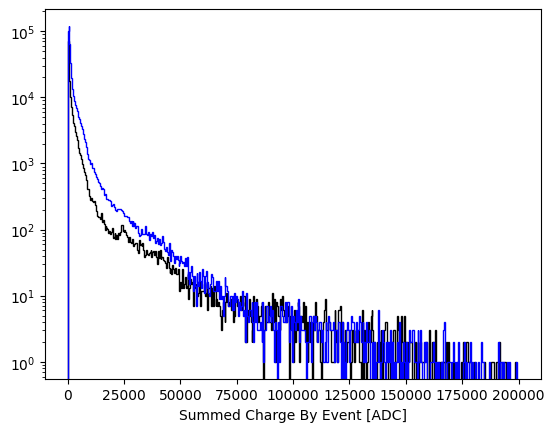

In [ ]:
plt.hist(total_charge_by_event_bkg, 500, histtype="step", range=(0, 200e3));
plt.hist(total_charge_by_event_sig, 500, histtype="step", range=(0, 200e3));
plt.xlabel("Summed Charge By Event [ADC]");
plt.yscale("log");

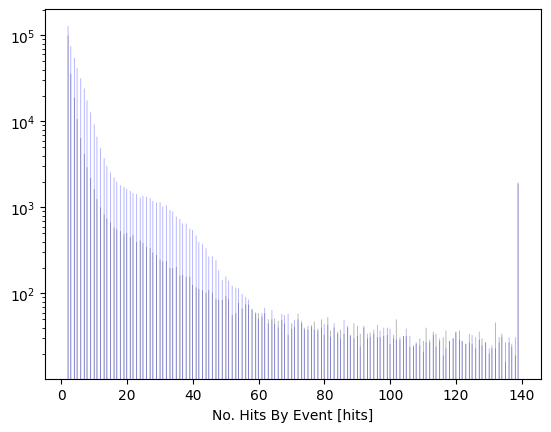

In [ ]:
plt.hist(total_nhits_by_event_bkg, 500, histtype="stepfilled", alpha=0.3);
plt.hist(total_nhits_by_event_sig, 500, histtype="stepfilled", alpha=0.3);
plt.xlabel("No. Hits By Event [hits]");
plt.yscale("log");

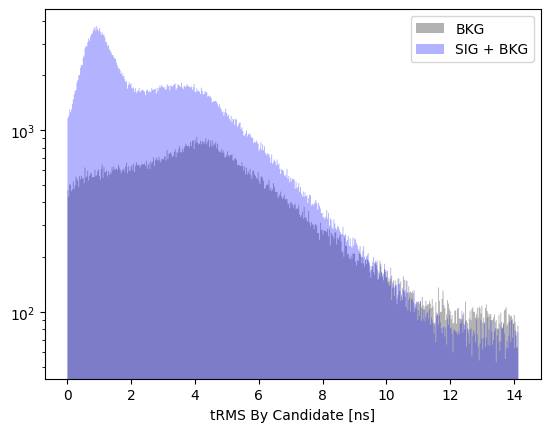

In [ ]:
plt.hist(total_trms_by_event_bkg, 500, histtype="stepfilled", alpha=0.3, label="BKG");
plt.hist(total_trms_by_event_sig, 500, histtype="stepfilled", alpha=0.3, label="SIG + BKG");
plt.xlabel("tRMS By Candidate [ns]");
plt.yscale("log");
plt.legend();

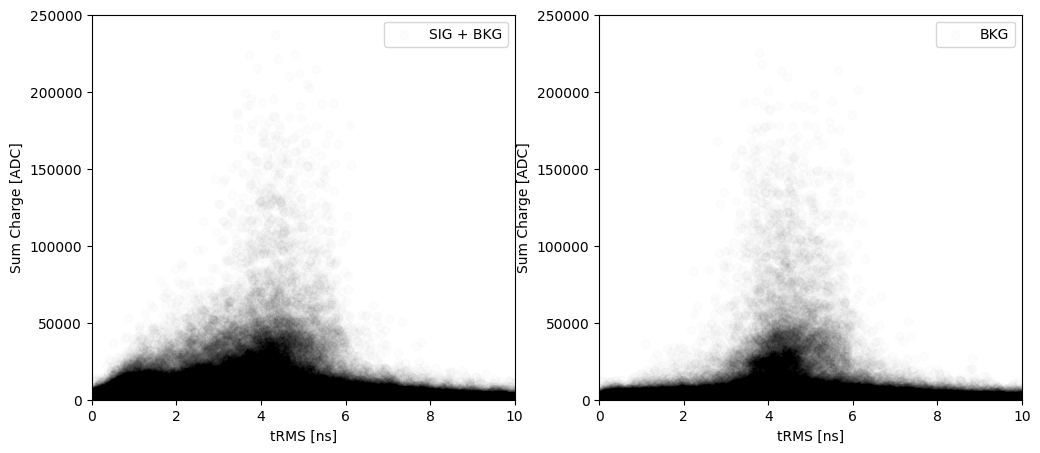

In [ ]:
subplot = pltext.canvas(2)

subplot(1)
plt.scatter(total_trms_by_event_sig, total_charge_by_event_sig, alpha=0.01, label="SIG + BKG");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);
plt.legend()

subplot(2)
plt.scatter(total_trms_by_event_bkg, total_charge_by_event_bkg, alpha=0.01, label="BKG");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);
plt.legend();

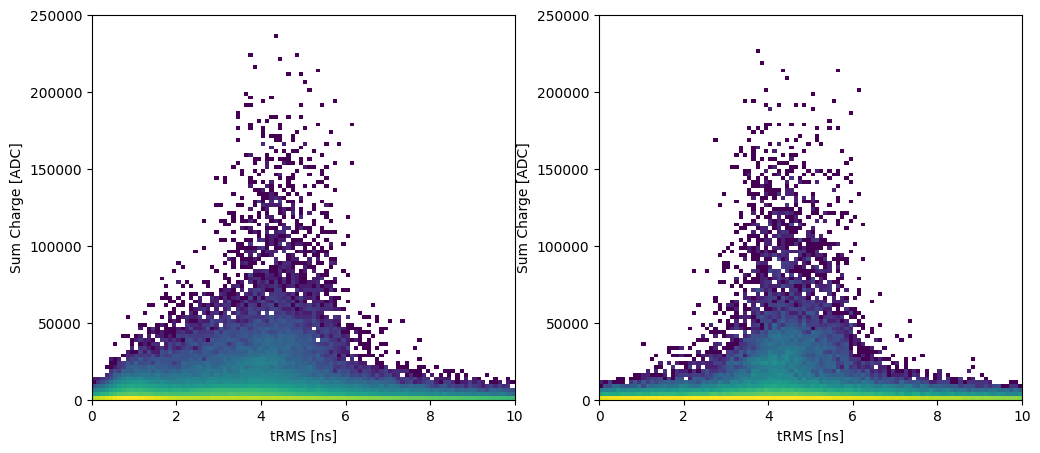

In [ ]:
subplot = pltext.canvas(2)

subplot(1)
plt.hist2d(total_trms_by_event_sig, total_charge_by_event_sig, (100, 100), range=((0, 10), (0, 250e3)), norm="log");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);

subplot(2)
plt.hist2d(total_trms_by_event_bkg, total_charge_by_event_bkg, (100, 100), range=((0, 10), (0, 250e3)), norm="log");
plt.xlabel("tRMS [ns]")
plt.ylabel("Sum Charge [ADC]")
plt.ylim(0, 250e3);
plt.xlim(0, 10);